In [17]:

import numpy as np
import os
import glob
import json
import random
import math
import builtins
import sys
import csv
import folium
import platform
import subprocess
import networkx as nx
import pandas as pd
import torch
import torch_geometric
import torch.nn as nn
import torch.nn.functional as torch_fn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib as mpl
import matplotlib.image as mpimg
import hdbscan

from io import *
from typing import *
from pathlib import Path
from datetime import datetime
from networkx import DiGraph
from functools import reduce
from pyspark.sql import *
from pyspark.sql.window import Window as ww
from pyspark.sql import functions as fn
from matplotlib.figure import *
from matplotlib.container import *
from torch import Tensor
# from torch.nn import *
from torch.nn import Module, LayerNorm
from torch.nn.utils import clip_grad_norm_
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GAE, VGAE, DeepGraphInfomax
from torch_geometric.utils import to_undirected, coalesce, negative_sampling
from torch_geometric.transforms import RandomLinkSplit
from torch.optim import Adam
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


data_dir = '/data/geolocation-data/processed/cell_traces'
normalization_dir = f'{data_dir}/normalization'
aggregation_dir = f'{data_dir}/aggregation'
master_site_dir = '/data/geolocation-data/processed/master_site'
initial_dir = f'{data_dir}/initial'
join_dir = f'{data_dir}/join'
anti_join_dir = f'{data_dir}/anti_join'
top_k_dir = f'{data_dir}/top_k'
edges_dir = f'{data_dir}/edges'
edges_undirected_dir = f'{data_dir}/edges-undirected'
edges_grouping_dir = f'{data_dir}/edges-grouping'
node_final_dir = f'{data_dir}/node-final'
foundation_dir = f'{data_dir}/foundation'
model_training_result_path = f'{data_dir}/model_training_result'
clustering_result_path = f'{data_dir}/clustering_result'


spark = SparkSession.builder \
    .config("spark.driver.memory", "32g") \
    .config("spark.memory.fraction", "0.8") \
    .appName("CellTraces") \
    .master("local[*]") \
    .getOrCreate()


spark.sparkContext.setLogLevel("INFO")

spark.conf.set("spark.sql.debug.maxToStringFields", 10000)
spark.conf.set("spark.hadoop.mapreduce.input.fileinputformat.input.dir.recursive", "true")
spark.conf.set("mapreduce.input.fileinputformat.input.dir.recursive", "true")
spark.conf.set("fs.globstatus.glob.recursive", "true")

<h3>Hyperparameter Variables</h3>


In [18]:
# quantile error threshold
QUANTILE_RELATIVE_ERROR_THRESHOLD: float = 0.001

# top_k value to show or sample
# K_VALUE: int = 300
K_VALUE: int = 1000

# edge weight preprocess
CAP_QUANTILE_THRESHOLD: float = 0.99
EPS_THRESHOLD: float = 1e-12

# multi-run randomness seeds
RUN_SEEDS = [0, 1, 2, 3, 4]


# ================================================================================
# Hyperparamter Value for Manual Training
# ================================================================================

# training controls
PATIENCE: int = 50
MAX_EPOCHS: int = 10000
LOG_EVERY: int = 10
LEARNING_RATE: float = 1e-3
# LEARNING_RATE_GAE: float = 2e-4
WEIGHT_DECAY: float = 5e-4

# model architecture control
HIDDEN_CHANNELS: int = 128      # control encoder (GraphSAGE) capacity
LATENT_CHANNELS: int = 64       # control embedding size used for clustering

# regularization controls
DROPOUT: float = 0.20           # reduce overfitting

# early stopping behavior
MIN_EPOCH_BEFORE_EARLY_STOPPING: int = 100
MIN_DELTA: float = 1e-3

# optional EMA smoothing for GAE early stopping metric
USE_EMA_FOR_EARLY_STOPPING: bool = False
EMA_BETA: float = 0.80

# stability
GRAD_CLIP_NORM: Optional[float] = 0.1
NORMALIZE_Z_BEFORE_RECON: bool = True

# VGAE-specific
KL_BETA: float = 1e-6


# ================================================================================
# Hyperparamter Value for Automation Training
# ================================================================================
BASE_GAE = {
    "lr": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "hidden_channels": HIDDEN_CHANNELS,
    "latent_channels": LATENT_CHANNELS,
    "dropout": DROPOUT,
}


BASE_VGAE = {
    "lr": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "hidden_channels": HIDDEN_CHANNELS,
    "latent_channels": LATENT_CHANNELS,
    "dropout": DROPOUT,
    "kl_beta": KL_BETA,
}

BASE_DGI = {
    "lr": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "hidden_channels": HIDDEN_CHANNELS,
    "latent_channels": LATENT_CHANNELS,
    "dropout": DROPOUT,
}

HYPERPARAMETER_VALUES = {
    "lr": [5e-4, 8e-4, 1e-3, 1.2e-3, 1.5e-3],
    "weight_decay": [0.0, 1e-6, 1e-5, 1e-4, 1e-3],
    "hidden_channels": [32, 64, 96, 128, 192],
    "latent_channels": [16, 32, 48, 64, 96],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    # VGAE only
    "kl_beta": [0.001, 0.003, 0.005, 0.01, 0.02],
}


# clustering controls
EMB_DIM: int = 128
HDBSCAN_MIN_CLUSTER_SIZE: int = 30
HDBSCAN_MIN_SAMPLES: int = 10
DBSCAN_EPS: int = 0.5

<h3>Common Functions</h3>


In [19]:
# ==============================================================================
# Reproducibility utilities (run logs, split artifacts, environment snapshot)
# ==============================================================================

def _safe_cmd(cmd: List[str], cwd: Optional[str] = None) -> str:
    try:
        return subprocess.check_output(cmd, cwd=cwd, stderr=subprocess.STDOUT, text=True).strip()
    except Exception as e:
        return f"<unavailable: {type(e).__name__}: {e}>"


def make_run_id(prefix: str = "run") -> str:
    return f"{prefix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def collect_environment_snapshot() -> Dict[str, Any]:
    info: Dict[str, Any] = {
        "python_version": sys.version.replace("\n", " "),
        "platform": platform.platform(),
        "os": f"{platform.system()} {platform.release()}",
        "machine": platform.machine(),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_runtime": torch.version.cuda,
        "cudnn_version": torch.backends.cudnn.version(),
    }

    # torch-geometric version
    try:
        info["torch_geometric_version"] = getattr(torch_geometric, "__version__", "unknown")
    except Exception as e:
        info["torch_geometric_version"] = f"<unavailable: {type(e).__name__}: {e}>"

    # GPU info
    if torch.cuda.is_available():
        try:
            info["gpu_name"] = torch.cuda.get_device_name(0)
            info["gpu_count"] = torch.cuda.device_count()
            info["gpu_capability"] = ".".join(map(str, torch.cuda.get_device_capability(0)))
        except Exception as e:
            info["gpu_name"] = f"<unavailable: {type(e).__name__}: {e}>"

    # Dependency snapshot
    info["pip_freeze"] = _safe_cmd([sys.executable, "-m", "pip", "freeze"])

    # Optional conda export (if conda exists)
    # info["conda_env_export"] = _safe_cmd(["conda", "env", "export"])

    # Git snapshot (if this lives in a git repo)
    # info["git_commit"] = _safe_cmd(["git", "rev-parse", "HEAD"])
    # porcelain = _safe_cmd(["git", "status", "--porcelain"])
    # info["git_dirty"] = bool(porcelain and not porcelain.startswith("<unavailable") and porcelain != "")
    # info["git_status_porcelain"] = porcelain

    return info


def save_json(obj: Dict[str, Any], path: Path) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def init_runs_csv(path: Path, fieldnames: List[str]) -> None:
    if not path.exists():
        with path.open("w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader()


def append_runs_csv(path: Path, fieldnames: List[str], row: Dict[str, Any]) -> None:
    clean = {k: row.get(k, "") for k in fieldnames}
    with path.open("a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writerow(clean)

<h3>All Functions for building PLOT :</h3>
<ol>
    <li>Plot #1 --- Joined & Dropped data result</li>
    <li>Plot #2 --- Feature transform on skewed columns</li>
    <li>Plot #3 --- Edge weight distribution + preprocessing</li>
    <li>Plot #4 --- Graph Topology and Connectivity Analysis</li>
    <li>Plot #5 --- Training History for VGAE, GAE, DGI</li>
</ol>


In [20]:
# ==============================================================================================================================================
# Cell Topology based on static background
# ==============================================================================================================================================

def buildCellOverlayTopology(df_edges: DataFrame, df_node_final: DataFrame) -> None:
    # ===========================================================================================
    # Build Topology plot based on geo coordinates (long lat), with per-cell offset using AZIMUTH
    # Cell within same site_id will be grouped by same color
    # ===========================================================================================

    df_nodes_in_subgraph: Optional[DataFrame] = None
    df_edges_subgraph: Optional[DataFrame] = None
    df_nodes_attr: Optional[DataFrame] = None
    edges_pd: Optional[pd.DataFrame] = None
    nodes_pd: Optional[pd.DataFrame] = None
    graph: Optional[DiGraph] = None

    top_edges_count = K_VALUE

    pos = None
    valid_nodes = None

    src_index_column_name = "SOURCE_INDEX"
    dst_index_column_name = "DEST_INDEX"
    ho_count_column_name = "HO_COUNT"
    node_index_column_name = "NODE_INDEX"
    site_id_column_name = "SITEID"
    ho_total_column_name = "HO_TOTAL"
    out_ho_sum_column_name = "OUT_HO_SUM"
    in_ho_sum_column_name = "IN_HO_SUM"
    lon_column_name = "LONGITUDE"
    lat_column_name = "LATITUDE"
    azimuth_column_name = "AZIMUTH"
    ho_total_column_name = "HO_TOTAL"

    SEED = 999

    # visual spacing around tower coordinate for each cell (meters)
    OFFSET_METERS = 100.0
    # OFFSET_METERS = 300.0

    # ==============================================================================
    # 1) build edges data based on df_edges
    # ==============================================================================
    df_edges_subgraph = (
        df_edges.select(
            src_index_column_name,
            dst_index_column_name,
            ho_count_column_name,
        )
        .where(fn.col(ho_count_column_name).isNotNull())
        .orderBy(fn.col(ho_count_column_name).desc())
        # .limit(top_edges_count)
        # .limit(100000)
    )

    edges_pd = df_edges_subgraph.toPandas()

    # ==============================================================================
    # 2) build nodes data based on df_edges_subgraph
    # ==============================================================================
    df_nodes_in_subgraph = (
        df_edges_subgraph.select(fn.col(src_index_column_name).alias(node_index_column_name))
        .union(df_edges_subgraph.select(fn.col(dst_index_column_name).alias(node_index_column_name)))
        .distinct()
    )

    # ==============================================================================
    # 3) join node attributes for plotting
    # ==============================================================================
    df_nodes_attr = (
        df_nodes_in_subgraph.join(
            df_node_final.select(
                node_index_column_name,
                site_id_column_name,
                ho_total_column_name,
                out_ho_sum_column_name,
                in_ho_sum_column_name,
                lon_column_name,
                lat_column_name,
                azimuth_column_name,
            ),
            on=node_index_column_name,
            how="left",
        )
        .fillna(0, subset=[ho_total_column_name, out_ho_sum_column_name, in_ho_sum_column_name])
    )

    nodes_pd = df_nodes_attr.toPandas()

    # ==============================================================================
    # 4) Build NetworkX DiGraph with node attributes
    # ==============================================================================
    graph = nx.DiGraph()

    for r in nodes_pd.itertuples(index=False):
        node_id = int(getattr(r, node_index_column_name))
        node_weight = float(getattr(r, ho_total_column_name))

        siteid = getattr(r, site_id_column_name, None)
        lon = getattr(r, lon_column_name, None)
        lat = getattr(r, lat_column_name, None)
        az = getattr(r, azimuth_column_name, None)

        graph.add_node(
            node_id,
            node_weight=node_weight,
            siteid=siteid,
            longitude=lon,
            latitude=lat,
            azimuth=az,
        )

    for r in edges_pd.itertuples(index=False):
        graph.add_edge(
            int(getattr(r, src_index_column_name)),
            int(getattr(r, dst_index_column_name)),
            edge_weight=float(getattr(r, ho_count_column_name)),
        )

    print(f"[NetworkX] nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}")

    # ==============================================================================
    # 5) Build geo position with AZIMUTH offset
    # ==============================================================================
    randomNumberGenerator = np.random.default_rng(SEED)

    pos = {}
    valid_nodes = 0

    for n in graph.nodes():
        lon = graph.nodes[n].get("longitude", None)
        lat = graph.nodes[n].get("latitude", None)
        az = graph.nodes[n].get("azimuth", None)

        if lon is None or lat is None:
            continue

        try:
            lon = float(lon)
            lat = float(lat)
        except Exception:
            continue

        if not np.isfinite(lon) or not np.isfinite(lat):
            continue

        meters_per_deg_lat = 111_320.0
        dlat = OFFSET_METERS / meters_per_deg_lat

        meters_per_deg_lon = 111_320.0 * float(np.cos(np.deg2rad(lat)))
        if meters_per_deg_lon <= 1e-6:
            meters_per_deg_lon = 1e-6
        dlon = OFFSET_METERS / meters_per_deg_lon

        az_ok = True
        try:
            az = float(az)
        except Exception:
            az_ok = False

        if (not az_ok) or (not np.isfinite(az)):
            jx, jy = randomNumberGenerator.normal(0.0, 0.15, size=2)
            pos[n] = (lon + dlon * jx, lat + dlat * jy)
            valid_nodes += 1
            continue

        theta = float(np.deg2rad(az))
        dx = dlon * float(np.cos(theta))
        dy = dlat * float(np.sin(theta))

        pos[n] = (lon + dx, lat + dy)
        valid_nodes += 1

    print(f"[GEO] nodes_with_valid_lonlat={valid_nodes} out_of_total={graph.number_of_nodes()}")

    missing_pos = [n for n in graph.nodes() if n not in pos]
    if missing_pos:
        graph.remove_nodes_from(missing_pos)
        print(
            f"[GEO] removed_no_lonlat={len(missing_pos)} "
            f"remaining_nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}"
        )

    # ==============================================================================
    # 6) Prepare sizes, colors, edge widths
    # - node size based on node_weight
    # - color based on SITEID (color may repeat)
    # ==============================================================================
    node_w = np.array(
        [graph.nodes[node].get("node_weight", 0.0) for node in graph.nodes()],
        dtype=np.float64,
    )

    # ===============================================
    # Node size logic
    # ===============================================
    if node_w.size == 0 or node_w.max() <= 0:
        node_sizes = np.full_like(node_w, 10.0, dtype=np.float64)
    else:
        node_sizes = 5.0 + 40.0 * (np.log1p(node_w) / (np.log1p(node_w.max()) + 1e-12))

    # ===============================================
    # Site color logic
    # ===============================================
    # SITEID list aligned with graph.nodes() order
    site_ids = [str(graph.nodes[n].get("siteid", "UNKNOWN")) for n in graph.nodes()]

    # build stable SITEID -> index mapping (no hash % collisions)
    unique_site_ids = sorted(set(site_ids))
    # print(f"unique siteid: {len(set(unique_site_ids))}")

    randomNumberGenerator_colors = np.random.default_rng(SEED)   # change seed if you want different randomization

    # shuffle it
    randomNumberGenerator_colors.shuffle(unique_site_ids)
    # for i in range(SEED):
    #     randomNumberGenerator_colors.shuffle(unique_site_ids)

    # will have unique color based on size of unique_site_ids
    n_colors = builtins.max(1, len(unique_site_ids))
    site_to_idx = {sid: i for i, sid in enumerate(unique_site_ids)}

    palette = plt.get_cmap("hsv", n_colors)

    node_colors = [palette(int(site_to_idx.get(sid, 0))) for sid in site_ids]

    # edge widths
    edge_w = np.array(
        [graph.edges[e].get("edge_weight", 0.0) for e in graph.edges()],
        dtype=np.float64,
    )
    if edge_w.size == 0 or edge_w.max() <= 0:
        edge_widths = 0.2
    else:
        edge_widths = 0.05 + 1.5 * (np.log1p(edge_w) / (np.log1p(edge_w.max()) + 1e-12))
    # ==============================================================================
    # 7) Draw with a proper Axes
    # NOTE: removed colorbar because colors are categorical (SITEID)
    # ==============================================================================
    fig, ax = plt.subplots(figsize=(18, 12), dpi=200)

    # ==============================================================================
    # Display bogor_city_map for overlay
    # ==============================================================================
    bg_path = "/data/repository/repo.lti-cloud/development/s2-bgp/thesis/images/bogor_city_map.jpg"
    bg = mpimg.imread(bg_path)

    xs = np.array([pos[n][0] for n in graph.nodes() if n in pos], dtype=np.float64)
    ys = np.array([pos[n][1] for n in graph.nodes() if n in pos], dtype=np.float64)

    extent_nodes = None

    if xs.size > 0 and ys.size > 0:
        lon_min, lon_max = float(xs.min()), float(xs.max())
        lat_min, lat_max = float(ys.min()), float(ys.max())

        pad_lon = (lon_max - lon_min) * 0.05
        pad_lat = (lat_max - lat_min) * 0.05

        extent_nodes = [
            lon_min - pad_lon,
            lon_max + pad_lon,
            lat_min - pad_lat,
            lat_max + pad_lat,
        ]

        CROP_TOP = 0.020
        CROP_BOTTOM = 0.98
        CROP_LEFT = 0.17
        CROP_RIGHT = 0.82

        h, w = bg.shape[0], bg.shape[1]
        y0 = int(CROP_TOP * h)
        y1 = int(CROP_BOTTOM * h)
        x0 = int(CROP_LEFT * w)
        x1 = int(CROP_RIGHT * w)

        y0 = builtins.max(0, y0)
        x0 = builtins.max(0, x0)
        y1 = builtins.min(h, y1)
        x1 = builtins.min(w, x1)

        bg_crop = bg[y0:y1, x0:x1]

        # BG zoom only: centered crop from bg_crop, then stretch back into extent_nodes
        BG_ZOOM = 1.06
        hc, wc = bg_crop.shape[0], bg_crop.shape[1]
        cy = hc // 2
        cx = wc // 2
        half_h = int((hc / 2) / BG_ZOOM)
        half_w = int((wc / 2) / BG_ZOOM)

        y0z = builtins.max(0, cy - half_h)
        y1z = builtins.min(hc, cy + half_h)
        x0z = builtins.max(0, cx - half_w)
        x1z = builtins.min(wc, cx + half_w)

        bg_zoomed = bg_crop[y0z:y1z, x0z:x1z]

        ax.imshow(
            bg_zoomed,
            extent=extent_nodes,
            origin="upper",
            alpha=0.35,
            zorder=0,
        )

    # ==============================================================================
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.75,
        ax=ax,
    )

    nx.draw_networkx_edges(
        graph,
        pos,
        width=edge_widths,
        alpha=0.0058,
        arrows=False,
        # arrows=True,
        # arrowstyle="-|>",
        # arrowsize=8,
        ax=ax,
    )

    # lock plot limits to the node extent (plot does not zoom)
    if extent_nodes is not None:
        ax.set_xlim(extent_nodes[0], extent_nodes[1])
        ax.set_ylim(extent_nodes[2], extent_nodes[3])

    ax.set_aspect("equal", adjustable="box")
    ax.autoscale(False)
    ax.set_autoscale_on(False)

    ax.set_title(
        f"Topology based on geo coordinates (AZIMUTH as the offset)\nSite represented by Color\n"
        f"Sites={len(unique_site_ids)} Edges={graph.number_of_edges()} Nodes={graph.number_of_nodes()}"
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


# =============================================================================
# Cell Topology using Folium, based on longitude and latitude
# =============================================================================
def buildCellGeolocationTopology(df_edges: DataFrame, df_node_final: DataFrame) -> None:
    # ===========================================================================================
    # Topology map using Folium
    # Node color by SITEID, node size by HO_TOTAL, edges by HO_COUNT
    # ===========================================================================================

    # ===========================================================================================
    # Build Topology plot based on geo coordinates (long lat), with per-cell offset using AZIMUTH
    # Cell within same site_id will be grouped by same color
    # ===========================================================================================

    df_nodes_in_subgraph: Optional[DataFrame] = None
    df_edges_subgraph: Optional[DataFrame] = None
    df_nodes_attr: Optional[DataFrame] = None
    edges_pd: Optional[pd.DataFrame] = None
    nodes_pd: Optional[pd.DataFrame] = None
    graph: Optional[DiGraph] = None

    top_edges_count = K_VALUE

    pos = None
    valid_nodes = None

    src_index_column_name = "SOURCE_INDEX"
    dst_index_column_name = "DEST_INDEX"
    ho_count_column_name = "HO_COUNT"
    node_index_column_name = "NODE_INDEX"
    site_id_column_name = "SITEID"
    ho_total_column_name = "HO_TOTAL"
    out_ho_sum_column_name = "OUT_HO_SUM"
    in_ho_sum_column_name = "IN_HO_SUM"
    lon_column_name = "LONGITUDE"
    lat_column_name = "LATITUDE"
    azimuth_column_name = "AZIMUTH"
    ho_total_column_name = "HO_TOTAL"

    SEED = 999

    # visual spacing around tower coordinate for each cell (meters)
    OFFSET_METERS = 5.0

    # ==============================================================================
    # 1) build edges data based on df_edges
    # ==============================================================================
    df_edges_subgraph = (
        df_edges.select(
            src_index_column_name,
            dst_index_column_name,
            ho_count_column_name,
        )
        .where(fn.col(ho_count_column_name).isNotNull())
        .orderBy(fn.col(ho_count_column_name).desc())
        # .limit(top_edges_count)
        # .limit(100000)
    )

    edges_pd = df_edges_subgraph.toPandas()

    # ==============================================================================
    # 2) build nodes data based on df_edges_subgraph
    # ==============================================================================
    df_nodes_in_subgraph = (
        df_edges_subgraph.select(fn.col(src_index_column_name).alias(node_index_column_name))
        .union(df_edges_subgraph.select(fn.col(dst_index_column_name).alias(node_index_column_name)))
        .distinct()
    )

    # ==============================================================================
    # 3) join node attributes for plotting
    # ==============================================================================
    df_nodes_attr = (
        df_nodes_in_subgraph.join(
            df_node_final.select(
                node_index_column_name,
                site_id_column_name,
                ho_total_column_name,
                out_ho_sum_column_name,
                in_ho_sum_column_name,
                lon_column_name,
                lat_column_name,
                azimuth_column_name,
            ),
            on=node_index_column_name,
            how="left",
        )
        .fillna(0, subset=[ho_total_column_name, out_ho_sum_column_name, in_ho_sum_column_name])
    )

    nodes_pd = df_nodes_attr.toPandas()

    # ==============================================================================
    # 4) Build NetworkX DiGraph with node attributes
    # ==============================================================================
    graph = nx.DiGraph()

    for r in nodes_pd.itertuples(index=False):
        node_id = int(getattr(r, node_index_column_name))
        node_weight = float(getattr(r, ho_total_column_name))

        siteid = getattr(r, site_id_column_name, None)
        lon = getattr(r, lon_column_name, None)
        lat = getattr(r, lat_column_name, None)
        az = getattr(r, azimuth_column_name, None)

        graph.add_node(
            node_id,
            node_weight=node_weight,
            siteid=siteid,
            longitude=lon,
            latitude=lat,
            azimuth=az,
        )

    for r in edges_pd.itertuples(index=False):
        graph.add_edge(
            int(getattr(r, src_index_column_name)),
            int(getattr(r, dst_index_column_name)),
            edge_weight=float(getattr(r, ho_count_column_name)),
        )

    print(f"[NetworkX] nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}")

    # ==============================================================================
    # 5) Build geo position with AZIMUTH offset
    # ==============================================================================
    randomNumberGenerator = np.random.default_rng(SEED)

    pos = {}
    valid_nodes = 0

    for n in graph.nodes():
        lon = graph.nodes[n].get("longitude", None)
        lat = graph.nodes[n].get("latitude", None)
        az = graph.nodes[n].get("azimuth", None)

        if lon is None or lat is None:
            continue

        try:
            lon = float(lon)
            lat = float(lat)
        except Exception:
            continue

        if not np.isfinite(lon) or not np.isfinite(lat):
            continue

        meters_per_deg_lat = 111_320.0
        dlat = OFFSET_METERS / meters_per_deg_lat

        meters_per_deg_lon = 111_320.0 * float(np.cos(np.deg2rad(lat)))
        if meters_per_deg_lon <= 1e-6:
            meters_per_deg_lon = 1e-6
        dlon = OFFSET_METERS / meters_per_deg_lon

        az_ok = True
        try:
            az = float(az)
        except Exception:
            az_ok = False

        if (not az_ok) or (not np.isfinite(az)):
            jx, jy = randomNumberGenerator.normal(0.0, 0.15, size=2)
            pos[n] = (lon + dlon * jx, lat + dlat * jy)
            valid_nodes += 1
            continue

        theta = float(np.deg2rad(az))
        dx = dlon * float(np.cos(theta))
        dy = dlat * float(np.sin(theta))

        pos[n] = (lon + dx, lat + dy)
        valid_nodes += 1

    print(f"[GEO] nodes_with_valid_lonlat={valid_nodes} out_of_total={graph.number_of_nodes()}")

    missing_pos = [n for n in graph.nodes() if n not in pos]
    if missing_pos:
        graph.remove_nodes_from(missing_pos)
        print(
            f"[GEO] removed_no_lonlat={len(missing_pos)} "
            f"remaining_nodes={graph.number_of_nodes()} edges={graph.number_of_edges()}"
        )

    # ==============================================================================
    # 6) Prepare sizes, colors, edge widths (same intent as your block)
    # ==============================================================================
    node_w = np.array(
        [graph.nodes[node].get("node_weight", 0.0) for node in graph.nodes()],
        dtype=np.float64,
    )

    if node_w.size == 0 or node_w.max() <= 0:
        node_sizes = np.full_like(node_w, 10.0, dtype=np.float64)
    else:
        node_sizes = 5.0 + 40.0 * (np.log1p(node_w) / (np.log1p(node_w.max()) + 1e-12))

    site_ids = [str(graph.nodes[n].get("siteid", "UNKNOWN")) for n in graph.nodes()]
    unique_site_ids = sorted(set(site_ids))

    randomNumberGenerator_colors = np.random.default_rng(SEED)
    randomNumberGenerator_colors.shuffle(unique_site_ids)

    n_colors = builtins.max(1, len(unique_site_ids))
    site_to_idx = {sid: i for i, sid in enumerate(unique_site_ids)}

    palette = plt.get_cmap("hsv", n_colors)
    node_colors = [palette(int(site_to_idx.get(sid, 0))) for sid in site_ids]

    edge_w = np.array(
        [graph.edges[e].get("edge_weight", 0.0) for e in graph.edges()],
        dtype=np.float64,
    )
    if edge_w.size == 0 or edge_w.max() <= 0:
        edge_widths = 0.2
    else:
        edge_widths = 0.05 + 1.5 * (np.log1p(edge_w) / (np.log1p(edge_w.max()) + 1e-12))

    # ==============================================================================
    # 7) Folium map render
    # ==============================================================================

    def rgba_to_hex(rgba) -> str:
        r = int(float(rgba[0]) * 255)
        g = int(float(rgba[1]) * 255)
        b = int(float(rgba[2]) * 255)
        return "#{:02x}{:02x}{:02x}".format(r, g, b)

    # map center
    all_lons = np.array([pos[n][0] for n in graph.nodes() if n in pos], dtype=np.float64)
    all_lats = np.array([pos[n][1] for n in graph.nodes() if n in pos], dtype=np.float64)

    center_lat = float(all_lats.mean()) if all_lats.size > 0 else -6.595
    center_lon = float(all_lons.mean()) if all_lons.size > 0 else 106.817

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles="OpenStreetMap",
    )

    # build node index arrays
    graph_nodes_list = list(graph.nodes())
    node_id_to_i = {node_id: i for i, node_id in enumerate(graph_nodes_list)}

    # marker radius scaling for Folium
    if node_sizes.size > 0:
        ns_min = float(node_sizes.min())
        ns_max = float(node_sizes.max())
    else:
        ns_min = 0.0
        ns_max = 1.0

    def scale_radius(s: float) -> float:
        if ns_max <= ns_min:
            return 4.0
        t = (s - ns_min) / (ns_max - ns_min)
        return 2.0 + 6.0 * float(t)

    # draw edges (limit for performance)
    # MAX_EDGES_TO_DRAW = 50000
    MAX_EDGES_TO_DRAW = graph.number_of_edges()

    edges_list = list(graph.edges(data=True))
    if len(edges_list) > MAX_EDGES_TO_DRAW:
        edges_list = sorted(
            edges_list,
            key=lambda e: float(e[2].get("edge_weight", 0.0)),
            reverse=True,
        )[:MAX_EDGES_TO_DRAW]

    for u, v, data in edges_list:
        if (u not in pos) or (v not in pos):
            continue

        lon_u, lat_u = pos[u]
        lon_v, lat_v = pos[v]

        try:
            lat_u = float(lat_u)
            lon_u = float(lon_u)
            lat_v = float(lat_v)
            lon_v = float(lon_v)
        except Exception:
            continue

        folium.PolyLine(
            locations=[(lat_u, lon_u), (lat_v, lon_v)],
            color="#000000",
            weight=1,
            # opacity=0.1,
            opacity=0.008,
        ).add_to(m)

    # draw nodes
    for node_id in graph_nodes_list:
        if node_id not in pos:
            continue

        lon, lat = pos[node_id]
        try:
            lat = float(lat)
            lon = float(lon)
        except Exception:
            continue

        i = node_id_to_i[node_id]
        color_hex = rgba_to_hex(node_colors[i])
        radius = scale_radius(float(node_sizes[i]))

        sid = str(graph.nodes[node_id].get("siteid", "UNKNOWN"))
        ho_total_val = float(graph.nodes[node_id].get("node_weight", 0.0))

        folium.CircleMarker(
            location=(lat, lon),
            radius=radius,
            color=color_hex,
            fill=True,
            fill_color=color_hex,
            fill_opacity=0.85,
            opacity=0.85,
            tooltip=f"node={node_id} siteid={sid} ho_total={ho_total_val:.1f}",
        ).add_to(m)

    # Save to file:
    m.save("/home/arry/Downloads/topology_bogor.html")


# ==============================================================================================================================================
# Joined & Dropped data result
# ==============================================================================================================================================

def buildJoined_DroppedResultPlot(df_agg: DataFrame, df_master_site: DataFrame) -> None:

    df_plot_ct_with_key: Optional[DataFrame] = None
    df_plot_ms_with_key: Optional[DataFrame] = None
    df_plot_matched: Optional[DataFrame] = None
    df_plot_dropped: Optional[DataFrame] = None
    count_source_cells: Optional[int] = None
    count_matched_cells: Optional[int] = None
    count_dropped_cells: Optional[int] = None
    is_valid_join_Key: Optional[bool] = None
    percent_matched: Optional[float] = None
    percent_dropped: Optional[float] = None
    bar_labels: Optional[List[str]] = None
    bar_counts: Optional[List[float]] = None
    bar_percents: Optional[List[float]] = None

    bars: Optional[BarContainer] = None

    plot1_mod_cell_id_col_name = "MOD_CELL_ID"   # column in df_master_site
    plot1_source_cell_id_col_name = "SRC_CELL_ID"   # column in df_agg

    # ==========================================================================
    # 1) Build normalized join key (trim + upper) without touching original DFs
    # ==========================================================================

    df_plot_ct_with_key = (
        df_agg
        .withColumn("plot_join_key", fn.trim(fn.upper(fn.col(plot1_source_cell_id_col_name))))
    )

    df_plot_ms_with_key = (
        df_master_site
        .withColumn("plot_join_key", fn.trim(fn.upper(fn.col(plot1_mod_cell_id_col_name))))
    )

    # ==========================================================================
    # 2) Matched (inner join) + Dropped (left_anti)
    # ==========================================================================
    df_plot_matched = df_plot_ct_with_key.join(
        df_plot_ms_with_key,
        on="plot_join_key",
        how="inner"
    )

    df_plot_dropped = df_plot_ct_with_key.join(
        df_plot_ms_with_key,
        on="plot_join_key",
        how="left_anti"
    )

    # ==========================================================================
    # 3) Count DISTINCT join keys (unique cells)
    # ==========================================================================
    is_valid_join_Key = (fn.col("plot_join_key").isNotNull()) & (fn.col("plot_join_key") != "")

    count_source_cells = (
        df_plot_ct_with_key
        .where(is_valid_join_Key)
        .select("plot_join_key").distinct()
        .count()
    )

    count_matched_cells = (
        df_plot_matched
        .where(is_valid_join_Key)
        .select("plot_join_key").distinct()
        .count()
    )

    count_dropped_cells = (
        df_plot_dropped
        .where(is_valid_join_Key)
        .select("plot_join_key").distinct()
        .count()
    )

    # ==========================================================================
    # 4) Sanity check
    # ==========================================================================
    print(f"[PLOT] count_source_cells  : {count_source_cells}")
    print(f"[PLOT] count_matched_cells : {count_matched_cells}")
    print(f"[PLOT] count_dropped_cells : {count_dropped_cells}")
    print(f"[PLOT] Check (matched + dropped == source): {count_matched_cells + count_dropped_cells == count_source_cells}")

    # ==========================================================================
    # 5) Percentages
    # ==========================================================================
    if count_source_cells > 0:
        percent_matched = (count_matched_cells / count_source_cells) * 100.0
        percent_dropped = (count_dropped_cells / count_source_cells) * 100.0
    else:
        percent_matched = 0.0
        percent_dropped = 0.0

    # ==========================================================================
    # 6) Plot bar chart (counts + percent labels)
    # ==========================================================================
    bar_labels = ["Source (df_agg)", "Matched (inner join)", "Dropped (left_anti)"]
    bar_counts = [count_source_cells, count_matched_cells, count_dropped_cells]
    bar_percents = [100.0, percent_matched, percent_dropped]

    plt.figure(figsize=(9, 4))
    bars = plt.bar(bar_labels, bar_counts)


# ==============================================================================================================================================
# Feature transform on skewed columns
# ==============================================================================================================================================

def buildFeatureColumNameAndIndices(feature_cols: List, skew_cols: List) -> Tuple[List[str], List[int]]:

    preferred_skew_columns = [
        "TOTAL_CALLS",
        "TOTAL_SUCCESS_CALLS",
        "TOTAL_DROP_CALLS",
        "TOTAL_BLOCK_CALLS",
        "TOTAL_CSFB_CALLS",
        "TOTAL_SETUP_FAIL_CALLS",
        "CELL_TOTAL_DL_VOLUME",
        "CELL_TOTAL_UL_VOLUME",
        "CELL_TOTAL_PING_PONG_HO_COUNT",
        "OUT_HO_SUM",
        "IN_HO_SUM",
        "HO_TOTAL",
        "OUT_EDGE_COUNT",
        "IN_EDGE_COUNT",
        "OUT_NEIGHBOR_COUNT",
        "IN_NEIGHBOR_COUNT",
    ]

    Plot_column_names = [c for c in preferred_skew_columns if (c in feature_cols and c in skew_cols)]
    if len(Plot_column_names) < 3:
        # fallback: take first available skew columns
        Plot_column_names = [c for c in feature_cols if c in skew_cols][:5]

    # Map to indices in node_features
    Plot_column_indices = [feature_cols.index(c) for c in Plot_column_names]

    return Plot_column_names, Plot_column_indices


def FeaturePrintStats(values: np.ndarray, title: str) -> None:
    values = values[np.isfinite(values)]
    if values.size == 0:
        print(f"[Plot] {title}: no finite values")
        return
    p50 = float(np.percentile(values, 50))
    p95 = float(np.percentile(values, 95))
    p99 = float(np.percentile(values, 99))
    print(f"[Plot] {title}\nmin={float(values.min()):.6f}  p50={p50:.6f}  p95={p95:.6f}  p99={p99:.6f}  max={float(values.max()):.6f}")


def buildFeatureTransformForSkewedColumnPlot(
    node_features_after_log1p: np.ndarray,
    node_features_before_log1p: np.ndarray,
    Plot_column_names: List[str],
    Plot_column_indices: List[int],
    bins: int = 60
) -> None:

    if node_features_after_log1p is None or node_features_before_log1p is None:
        raise ValueError("Plot : node_features arrays are None.")

    if len(Plot_column_names) == 0 or len(Plot_column_indices) == 0:
        raise ValueError("Plot : Plot_column_names/Plot_column_indices is empty.")

    if len(Plot_column_names) != len(Plot_column_indices):
        raise ValueError("Plot : Plot_column_names and Plot_column_indices length mismatch.")

    if node_features_after_log1p.shape != node_features_before_log1p.shape:
        raise ValueError(
            f"Plot : shape mismatch. before={node_features_before_log1p.shape}, after={node_features_after_log1p.shape}"
        )

    num_features = node_features_after_log1p.shape[1]

    # formatter: show full numbers, no scientific notation
    def format_plain_number(x, _pos):
        # Use comma for big values; if you want no comma, change to f"{x:.0f}"
        return f"{x:,.0f}"

    for col_index, col_name in zip(Plot_column_indices, Plot_column_names):
        if col_index < 0 or col_index >= num_features:
            print(f"[Plot] Skip {col_name}: invalid col_index={col_index}")
            continue

        before_values = node_features_before_log1p[:, col_index].astype(np.float64)
        after_values = node_features_after_log1p[:, col_index].astype(np.float64)

        before_values = before_values[np.isfinite(before_values)]
        after_values = after_values[np.isfinite(after_values)]

        if before_values.size == 0 or after_values.size == 0:
            print(f"[Plot] Skip {col_name}: no finite values.")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(20, 4))

        # LEFT: raw
        axes[0].hist(before_values, bins=bins)
        axes[0].set_title(f"{col_name} — Before applying log1p")
        axes[0].set_xlabel(col_name)
        axes[0].set_ylabel("Cell count")

        # Force full-number ticks + hide offset text
        axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(format_plain_number))
        axes[0].xaxis.get_offset_text().set_visible(False)

        # RIGHT: log1p
        axes[1].hist(after_values, bins=bins)
        axes[1].set_title(f"{col_name} — After applying log1p")
        axes[1].set_xlabel(f"log1p({col_name})")
        axes[1].set_ylabel("Cell count")

        # axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _pos: f"{x:.2f}"))
        axes[1].xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _pos: f"{x:.2f}".rstrip("0").rstrip("."))
        )
        axes[1].xaxis.get_offset_text().set_visible(False)

        # plt.suptitle(f"Plot #4 — log1p impact on {col_name}")
        # plt.tight_layout()
        # plt.show()

        fig.suptitle(f"Plot #4 — log1p impact on {col_name}")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        plt.close(fig)

# ==============================================================================================================================================
# Edge weight distribution + preprocessing
# ==============================================================================================================================================


def buildEdgeWeightDistributionPlot(
    edge_weight_before: np.ndarray,
    edge_weight_after: np.ndarray,
    bins: int = 60,
    title_prefix: str = "Edge weight distribution"
) -> None:

    before_values = edge_weight_before.astype(np.float64)
    after_values = edge_weight_after.astype(np.float64)

    before_values = before_values[np.isfinite(before_values)]
    after_values = after_values[np.isfinite(after_values)]

    if before_values.size == 0 or after_values.size == 0:
        raise ValueError("Plot: edge_weight arrays have no finite values.")

    def print_stats(values: np.ndarray, name: str) -> None:
        p50 = builtins.float(np.percentile(values, 50))
        p95 = builtins.float(np.percentile(values, 95))
        p99 = builtins.float(np.percentile(values, 99))
        print(
            f"[PLOT5] {name}\n"
            f"min={builtins.float(values.min()):.6f} "
            f"p50={p50:.6f} "
            f"p95={p95:.6f} "
            f"p99={p99:.6f} "
            f"max={builtins.float(values.max()):.6f} "
            f"mean={builtins.float(values.mean()):.6f}"
        )

    print_stats(before_values, "edge_weight BEFORE preprocess (raw HO count)")
    print_stats(after_values,  "edge_weight AFTER preprocess (log1p + cap + normalize)")

    # formatters
    def format_big_int(x, _pos):
        return f"{x:,.0f}"

    def format_trim_float(x, _pos):
        return f"{x:.2f}".rstrip("0").rstrip(".")

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))

    # LEFT: raw edge weight (HO count)
    axes[0].hist(before_values, bins=bins)
    axes[0].set_title("Before preprocess (raw HO count)")
    axes[0].set_xlabel("edge_weight (raw)")
    axes[0].set_ylabel("Edge count")
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(format_big_int))
    axes[0].xaxis.get_offset_text().set_visible(False)

    # RIGHT: processed edge weight (log1p + cap + normalize)
    axes[1].hist(after_values, bins=bins)
    axes[1].set_title("After preprocess (log1p + cap + normalize)")
    axes[1].set_xlabel("edge_weight (processed)")
    axes[1].set_ylabel("Edge count")
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(format_trim_float))
    axes[1].xaxis.get_offset_text().set_visible(False)

    fig.suptitle(title_prefix)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    plt.close(fig)

# ==============================================================================================================================================
# Graph Topology and Connectivity Analysis
# ==============================================================================================================================================


def buildGraphTopology_ConnectivityPlot(
    torch_data,
    bins_degree: int = 60,
    bins_weight: int = 60
) -> None:
    """
    Topology structure plots for the PyG graph.
    - Degree distribution (linear and log-log)
    - Connected component size distribution (top-N)
    - Edge weight distribution (optional quick view)
    - Degree vs mean edge weight per node
    """

    # ----------------------------
    # Validate inputs
    # ----------------------------
    if not hasattr(torch_data, "edge_index"):
        raise ValueError("Plot : torch_data has no edge_index")

    edge_index: torch.Tensor = torch_data.edge_index
    if edge_index is None or edge_index.numel() == 0:
        raise ValueError("Plot : edge_index is empty")

    num_nodes: int = builtins.int(torch_data.num_nodes)

    # ----------------------------
    # 1) Degree computation
    # ----------------------------
    src_nodes = edge_index[0].detach().cpu().numpy()
    dst_nodes = edge_index[1].detach().cpu().numpy()

    degree_values = np.bincount(
        np.concatenate([src_nodes, dst_nodes]),
        minlength=num_nodes
    ).astype(np.int64)

    # ----------------------------
    # Plot 1: Degree distribution (linear histogram)
    # ----------------------------
    plt.figure(figsize=(10, 4))
    plt.hist(degree_values, bins=bins_degree)
    plt.title("Plot A — Node degree distribution (linear scale)")
    plt.xlabel("Degree (number of incident edges)")
    plt.ylabel("Node count")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: Degree distribution (log-log: heavy-tail check)
    # ------------------------------------------------------------
    degree_positive = degree_values[degree_values > 0]
    if degree_positive.size > 0:
        unique_degree, degree_counts = np.unique(degree_positive, return_counts=True)

        plt.figure(figsize=(10, 4))
        plt.plot(unique_degree, degree_counts, marker="o", linestyle="None")
        plt.xscale("log")
        plt.yscale("log")
        plt.title("Plot B — Degree frequency (log-log)")
        plt.xlabel("Degree (log scale)")
        plt.ylabel("Frequency (log scale)")
        plt.tight_layout()
        plt.show()

    # ----------------------------
    # 2) Connected components
    # ----------------------------
    parent = np.arange(num_nodes, dtype=np.int64)
    rank = np.zeros(num_nodes, dtype=np.int64)

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: int, b: int) -> None:
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1

    # edges as undirected for component structure
    for a, b in zip(src_nodes, dst_nodes):
        union(int(a), int(b))

    roots = np.array([find(i) for i in builtins.range(num_nodes)], dtype=np.int64)
    unique_roots, component_sizes = np.unique(roots, return_counts=True)

    # Sort component sizes desc
    component_sizes_sorted = np.sort(component_sizes)[::-1]

    # ------------------------------------------------------------
    # Plot 3: Top component sizes
    # ------------------------------------------------------------
    top_n = 20 if component_sizes_sorted.size >= 20 else component_sizes_sorted.size
    plt.figure(figsize=(10, 4))
    plt.bar([str(i+1) for i in builtins.range(top_n)], component_sizes_sorted[:top_n])
    plt.title("Plot C — Largest connected components (top-N)")
    plt.xlabel("Component rank")
    plt.ylabel("Number of nodes")
    plt.tight_layout()
    plt.show()

    print(f"[PLOT6] num_nodes={num_nodes:,}  num_edges={edge_index.shape[1]:,}")
    print(f"[PLOT6] number_of_components={component_sizes_sorted.size:,}")
    if component_sizes_sorted.size > 0:
        print(f"[PLOT6] largest_component_size={int(component_sizes_sorted[0]):,}")
        print(f"[PLOT6] top5_component_sizes={component_sizes_sorted[:5].tolist()}")

    # ----------------------------
    # 3) Optional: Edge weight distribution + degree vs weight
    # ----------------------------
    if hasattr(torch_data, "edge_weight") and torch_data.edge_weight is not None:
        edge_weight_values = torch_data.edge_weight.detach().cpu().numpy().astype(np.float64)
        edge_weight_values = edge_weight_values[np.isfinite(edge_weight_values)]

        if edge_weight_values.size > 0:
            plt.figure(figsize=(10, 4))
            plt.hist(edge_weight_values, bins=bins_weight)
            plt.title("Plot D — Edge weight distribution (processed)")
            plt.xlabel("edge_weight")
            plt.ylabel("Edge count")
            plt.tight_layout()
            plt.show()

        # Degree vs mean edge weight per node
        # Compute sum weights per node
        weight_sum_per_node = np.zeros(num_nodes, dtype=np.float64)
        weight_cnt_per_node = np.zeros(num_nodes, dtype=np.int64)

        # Using directed edges as given (src -> dst)
        src_nodes_int = src_nodes.astype(np.int64)
        for idx_edge in builtins.range(src_nodes_int.size):
            s = int(src_nodes_int[idx_edge])
            w = float(edge_weight_values[idx_edge]) if idx_edge < edge_weight_values.size else 0.0
            weight_sum_per_node[s] += w
            weight_cnt_per_node[s] += 1

        mean_weight_per_node = np.divide(
            weight_sum_per_node,
            np.clip(weight_cnt_per_node, 1, None),
            dtype=np.float64
        )

        plt.figure(figsize=(10, 4))
        plt.scatter(degree_values, mean_weight_per_node, s=10)
        plt.title("Plot — Node degree vs mean outgoing edge_weight")
        plt.xlabel("Degree")
        plt.ylabel("Mean outgoing edge_weight")
        plt.tight_layout()
        plt.show()

# ==============================================================================================================================================
# Training History
# ==============================================================================================================================================


def init_history(model_tag: str) -> Dict[str, Any]:
    return {
        "model": model_tag,
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "ema_val_loss": [],
        "metric": [],
        "best_val": [],
        "best_metric": [],
    }


def _safe_float(x) -> float:
    try:
        v = float(x)
        if math.isnan(v) or math.isinf(v):
            return float("nan")
        return v
    except Exception:
        return float("nan")


def _plot_curves(
    history: Dict[str, Any],
    series: Tuple[Tuple[str, str], ...],
    title: str,
    out_path: Optional[str] = None,
    show: bool = False,
):
    x = history.get("epoch", [])
    if not x:
        raise ValueError(f"No points recorded for {history.get('model', 'unknown')}")

    fig = plt.figure()
    plotted_any = False

    for key, label in series:
        y = history.get(key, [])
        if not y:
            continue
        if builtins.len(y) != builtins.len(x):
            continue
        plt.plot(x, [_safe_float(v) for v in y], label=label)
        plotted_any = True

    if not plotted_any:
        plt.close(fig)
        raise ValueError(f"No valid series to plot for {history.get('model', 'unknown')}")

    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if out_path:
        fig.savefig(out_path, dpi=200)

    if show:
        # Notebook-safe display if available, else fallback to plt.show()
        try:
            from IPython.display import display
            display(fig)
        except Exception:
            plt.show()

    plt.close(fig)

    return fig

<h3>Class implementation function for VGAE, GAE, and DGI</h3>


In [21]:
# =========================================================
# Encoder class definition
# =========================================================

class GAEGraphSAGEEncoder(Module):
    """
    GraphSAGE encoder for GAE
    """

    def __init__(self, inputFeatures: int, hiddenChannels: int, latentChannels: int, dropout: float = 0.2):
        super().__init__()
        self.firstLayer = SAGEConv(inputFeatures, hiddenChannels)
        self.secondLayer = SAGEConv(hiddenChannels, latentChannels)
        self.dropout = dropout

    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = self.firstLayer(x, edge_index)
        x = torch_fn.relu(x)
        x = torch_fn.dropout(x, p=self.dropout, training=self.training)

        x = self.secondLayer(x, edge_index)

        return x


class VGAEGraphSAGEEncoder(Module):
    """
    Variational GraphSAGE encoder for VGAE.
    """

    def __init__(self, inputFeatures: int, hiddenChannels: int, latentChannels: int, dropout: float = 0.2):
        super().__init__()
        self.firstLayer = SAGEConv(inputFeatures, hiddenChannels)
        self.muLayer = SAGEConv(hiddenChannels, latentChannels)
        self.logstdLayer = SAGEConv(hiddenChannels, latentChannels)
        self.dropout = dropout

    def forward(self, x: Tensor, edge_index: Tensor) -> Tuple[Tensor, Tensor]:
        x = self.firstLayer(x, edge_index)
        x = torch_fn.relu(x)
        x = torch_fn.dropout(x, p=self.dropout, training=self.training)

        mu = self.muLayer(x, edge_index)
        logstd = self.logstdLayer(x, edge_index)

        # clamp the value of logstd to stabilize the result
        logstd = torch.clamp(logstd, min=-10.0, max=2.0)

        return mu, logstd


class DGIGraphSAGEEncoder(Module):
    def __init__(
        self,
        inputFeatures: int,
        hiddenChannels: int,
        latentChannels: int,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.firstLayer = SAGEConv(inputFeatures, hiddenChannels)
        self.secondLayer = SAGEConv(hiddenChannels, latentChannels)

        self.norm1 = LayerNorm(hiddenChannels)
        self.norm2 = LayerNorm(latentChannels)

        self.dropout = builtins.float(dropout)

    def forward(self, x: Tensor, edge_index: Tensor) -> Tensor:
        x = self.firstLayer(x, edge_index)
        x = self.norm1(x)
        x = torch_fn.relu(x)
        x = torch_fn.dropout(x, p=self.dropout, training=self.training)

        x = self.secondLayer(x, edge_index)
        x = self.norm2(x)
        return x


# =========================================================
# Model class definition
# =========================================================

class GAEModel(Module):
    """
    Wrapper around PyG GAE with GraphSAGE encoder.
    """

    def __init__(self, inputFeatures: int, hiddenChannels: int, latentChannels: int, dropout: float = 0.2):
        super().__init__()
        self.encoder = GAEGraphSAGEEncoder(inputFeatures, hiddenChannels, latentChannels, dropout=dropout)
        self.model = GAE(self.encoder)

    def encode(self, data) -> Tensor:
        x, edge_index = data.x, data.edge_index

        return self.model.encode(x, edge_index)

    def forward(self, data) -> Tensor:
        return self.encode(data)


class VGAEModel(Module):
    """
    Wrapper around PyG VGAE with variational GraphSAGE encoder.
    """

    def __init__(self, inputFeatures: int, hiddenChannels: int, latentChannels: int, dropout: float = 0.2):
        super().__init__()
        self.encoder = VGAEGraphSAGEEncoder(inputFeatures, hiddenChannels, latentChannels, dropout=dropout)
        self.model = VGAE(self.encoder)

    def encode(self, data) -> Tensor:
        x, edge_index = data.x, data.edge_index

        return self.model.encode(x, edge_index)

    def forward(self, data) -> Tensor:
        return self.encode(data)


class DGIModel(Module):
    def __init__(
        self,
        inputFeatures: int,
        hiddenChannels: int,
        latentChannels: int,
        dropout: float = 0.2,
    ):
        super().__init__()

        encoder = DGIGraphSAGEEncoder(
            inputFeatures=inputFeatures,
            hiddenChannels=hiddenChannels,
            latentChannels=latentChannels,
            dropout=dropout,
        )

        def corruption(x: Tensor, edge_index: Tensor) -> Tuple[Tensor, Tensor]:
            perm = torch.randperm(x.size(0), device=x.device)
            return x[perm], edge_index

        def summary(z: Tensor, *args, **kwargs) -> Tensor:
            return torch.mean(z, dim=0)

        self.model = DeepGraphInfomax(
            hidden_channels=latentChannels,
            encoder=encoder,
            summary=summary,
            corruption=corruption,
        )

    def forward(self, x: Tensor, edge_index: Tensor) -> Tuple[Tensor, Tensor, Tensor]:
        return self.model(x, edge_index)

    @torch.no_grad()
    def get_embedding(self, data: Data) -> Tensor:
        self.eval()
        device = next(self.parameters()).device
        x = data.x.to(device)
        edge_index = data.edge_index.to(device)
        z = self.model.encoder(x, edge_index)
        return z

In [22]:
# Model Variable Declaration

gaeModel: Optional[GAEModel] = None
vgaeModel: Optional[VGAEModel] = None
dgiModel: Optional[DGIModel] = None

<h3><h3>Model & Optimizer build function</h3>


In [23]:
ModelKind = Literal["gae", "vgae", "dgi"]


def buildModel(
    *,
    model_kind: ModelKind,
    inputFeatures: int,
    hiddenChannels: int,
    latentChannels: int,
    dropout: float,
    device: torch.device,
    log_prefix: str = "MODEL",
) -> torch.nn.Module:
    in_c = builtins.int(inputFeatures)
    hid_c = builtins.int(hiddenChannels)
    lat_c = builtins.int(latentChannels)
    drop = builtins.float(dropout)

    kind = builtins.str(model_kind).strip().lower()
    if kind not in ("gae", "vgae", "dgi"):
        raise ValueError(f"{log_prefix}: unknown model_kind={model_kind}")

    if kind == "gae":
        model: torch.nn.Module = GAEModel(
            inputFeatures=in_c,
            hiddenChannels=hid_c,
            latentChannels=lat_c,
            dropout=drop,
        )
    elif kind == "vgae":
        model = VGAEModel(
            inputFeatures=in_c,
            hiddenChannels=hid_c,
            latentChannels=lat_c,
            dropout=drop,
        )
    else:
        model = DGIModel(
            inputFeatures=in_c,
            hiddenChannels=hid_c,
            latentChannels=lat_c,
            dropout=drop,
        )

    model = model.to(device)

    total_params = builtins.int(builtins.sum(p.numel() for p in model.parameters()))
    trainable_params = builtins.int(builtins.sum(p.numel() for p in model.parameters() if p.requires_grad))

    if total_params <= 0 or trainable_params <= 0:
        raise RuntimeError(
            f"{log_prefix}: model_kind={kind} has no parameters "
            f"(total_params={total_params}, trainable_params={trainable_params})."
        )

    # Optional: show a tiny param breakdown for DGI since it was the trouble spot
    if kind == "dgi":
        encoder_params = builtins.int(
            builtins.sum(p.numel() for p in model.model.encoder.parameters())
        ) if hasattr(model, "model") and hasattr(model.model, "encoder") else -1

        print(
            f"{log_prefix}: kind = {kind}"
            f"\ninputFeatures = {in_c}"
            f"\nhiddenChannels = {hid_c}"
            f"\nlatentChannels = {lat_c}"
            f"\ndropout = {drop}"
            f"\nparams_total = {total_params}"
            f"\nparams_trainable = {trainable_params}"
            f"\nparams_encoder = {encoder_params}"
            f"\ndevice = {device.type}"
        )
    else:
        print(
            f"{log_prefix}: kind = {kind}"
            f"\ninputFeatures = {in_c}"
            f"\nhiddenChannels = {hid_c}"
            f"\nlatentChannels = {lat_c}"
            f"\ndropout = {drop}"
            f"\nparams_total = {total_params}"
            f"\nparams_trainable = {trainable_params}"
            f"\ndevice = {device.type}"
        )

    return model


def buildOptimizer(
    model: torch.nn.Module,
    *,
    model_kind: ModelKind,
    lr: float,
    weight_decay: float,
    log_prefix: str = "OPT"
) -> torch.optim.Optimizer:

    lr_f = builtins.float(lr)
    wd_f = builtins.float(weight_decay)

    params = list(model.parameters())
    if builtins.len(params) == 0:
        raise RuntimeError(f"{log_prefix}: model.parameters() is empty, cannot build optimizer")

    kind = builtins.str(model_kind).strip().lower()

    if kind == "dgi":
        optimizer = Adam(
            params,
            lr=lr_f,
            betas=(0.0, 0.999),
            weight_decay=wd_f
        )
        print(
            f"{log_prefix}: Adam (DGI no-momentum)"
            f"\nlr = {lr_f}"
            f"\nwd = {wd_f}"
            f"\nbetas = (0.0, 0.999)"
        )
    else:
        optimizer = Adam(
            params,
            lr=lr_f,
            weight_decay=wd_f
        )
        print(
            f"{log_prefix}: Adam"
            f"\nlr = {lr_f}"
            f"\nwd = {wd_f}"
        )

    opt_param_count = builtins.sum(builtins.len(g.get("params", [])) for g in optimizer.param_groups)
    if opt_param_count <= 0:
        raise RuntimeError(f"{log_prefix}: Adam has zero parameters wired in")

    return optimizer


def buildModelAndOptimizer(
    *,
    model_kind: ModelKind,
    inputFeatures: int,
    hiddenChannels: int,
    latentChannels: int,
    dropout: float,
    lr: float,
    weight_decay: float,
    device: torch.device,
    log_prefix: str = "MODEL"
) -> Tuple[torch.nn.Module, torch.optim.Optimizer]:

    model = buildModel(
        model_kind=model_kind,
        inputFeatures=inputFeatures,
        hiddenChannels=hiddenChannels,
        latentChannels=latentChannels,
        dropout=dropout,
        device=device,
        log_prefix=log_prefix
    )

    optimizer = buildOptimizer(
        model,
        model_kind=model_kind,
        lr=lr,
        weight_decay=weight_decay,
        log_prefix="OPT"
    )

    return model, optimizer

<h3>Training Function with Early Stopping</h3>


In [24]:
from torch.nn.utils import clip_grad_norm_
import torch
import numpy as np
import builtins
from typing import Any, Dict, List, Optional


def trainGAE(
    *,
    gaeModel,  # type: ignore
    gaeOptimizer: torch.optim.Optimizer,
    trainData: Data,
    valData: Data,
    max_epochs: int,
    patience: int,
    log_every: int,
    min_epoch_before_early_stopping: int = 100,
    use_ema_for_early_stopping: bool = False,
    ema_beta: float = 0.80,
    min_delta: float = 1e-3,
    grad_clip_norm: Optional[float] = 0.1,
    normalize_z_before_recon: bool = True,
    plot_curves: bool = False,
    log_prefix: str = "TRAIN_GAE",
) -> Dict[str, object]:

    max_epochs_i = builtins.int(max_epochs)
    patience_i = builtins.int(patience)
    log_every_i = builtins.int(log_every)
    min_es_i = builtins.int(min_epoch_before_early_stopping)

    ema_beta_f = builtins.float(ema_beta)
    min_delta_f = builtins.float(min_delta)

    device = next(gaeModel.parameters()).device

    best_metric = builtins.float("inf")
    best_epoch = -1
    best_state: Optional[Dict[str, torch.Tensor]] = None
    bad_count = 0

    ema_val_loss: Optional[float] = None

    history: Dict[str, List[float]] = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "ema_val_loss": [],
        "metric": [],
        "best_metric": [],
        "grad_norm": [],
        "grad_none_count": [],
        "grad_max_abs": [],
        "param_delta_l2": [],
        "z_norm_mean": [],
        "z_norm_max": [],
        "improved": [],
        "bad_count": [],
    }

    prev_params: Optional[Dict[str, torch.Tensor]] = None

    for epoch in builtins.range(1, max_epochs_i + 1):
        gaeModel.train()
        gaeOptimizer.zero_grad()

        z_train = gaeModel.encode(trainData)
        if normalize_z_before_recon:
            z_train = torch_fn.normalize(z_train, p=2.0, dim=1)

        with torch.no_grad():
            zn = torch.norm(z_train.detach(), p=2, dim=1)
            z_norm_mean = builtins.float(zn.mean().item()) if zn.numel() > 0 else 0.0
            z_norm_max = builtins.float(zn.max().item()) if zn.numel() > 0 else 0.0

        loss_t = gaeModel.model.recon_loss(
            z_train,
            trainData.pos_edge_label_index,
            trainData.neg_edge_label_index,
        )
        loss_t.backward()

        grad_none_count = 0
        grad_max_abs = 0.0
        for p in gaeModel.parameters():
            if p.grad is None:
                grad_none_count += 1
                continue
            g = p.grad.detach()
            if g.numel() > 0:
                max_abs = builtins.float(torch.max(torch.abs(g)).item())
                if max_abs > grad_max_abs:
                    grad_max_abs = max_abs

        if grad_clip_norm is not None:
            gn = clip_grad_norm_(gaeModel.parameters(), max_norm=builtins.float(grad_clip_norm))
            grad_norm_val = builtins.float(gn) if gn is not None else 0.0
        else:
            total = 0.0
            for p in gaeModel.parameters():
                if p.grad is None:
                    continue
                g = p.grad.detach()
                total += builtins.float(torch.sum(g * g).item())
            grad_norm_val = (builtins.float(total) ** 0.5) if total > 0.0 else 0.0

        if prev_params is None:
            prev_params = {k: v.detach().clone() for k, v in gaeModel.state_dict().items()}

        gaeOptimizer.step()

        with torch.no_grad():
            delta_sq = 0.0
            curr = gaeModel.state_dict()
            for k, v in curr.items():
                if k not in prev_params:
                    continue
                dv = (v.detach() - prev_params[k]).float()
                delta_sq += builtins.float(torch.sum(dv * dv).item())
            param_delta_l2 = (builtins.float(delta_sq) ** 0.5) if delta_sq > 0.0 else 0.0
            prev_params = {k: v.detach().clone() for k, v in curr.items()}

        train_loss_val = builtins.float(loss_t.detach().item())

        gaeModel.eval()
        with torch.no_grad():
            z_val = gaeModel.encode(trainData)
            if normalize_z_before_recon:
                z_val = torch_fn.normalize(z_val, p=2.0, dim=1)

            val_loss_t = gaeModel.model.recon_loss(
                z_val,
                valData.pos_edge_label_index,
                valData.neg_edge_label_index,
            )
            val_loss_val = builtins.float(val_loss_t.detach().item())

        if ema_val_loss is None:
            ema_val_loss = val_loss_val
        else:
            ema_val_loss = (ema_beta_f * ema_val_loss) + ((1.0 - ema_beta_f) * val_loss_val)

        metric = builtins.float(ema_val_loss) if use_ema_for_early_stopping else val_loss_val
        improved = metric < (best_metric - min_delta_f)

        if improved:
            best_metric = builtins.float(metric)
            best_epoch = builtins.int(epoch)
            best_state = {k: v.detach().cpu().clone() for k, v in gaeModel.state_dict().items()}
            bad_count = 0
        else:
            if epoch >= min_es_i:
                bad_count += 1

        history["epoch"].append(builtins.float(epoch))
        history["train_loss"].append(_safe_float(train_loss_val))
        history["val_loss"].append(_safe_float(val_loss_val))
        history["ema_val_loss"].append(_safe_float(ema_val_loss))
        history["metric"].append(_safe_float(metric))
        history["best_metric"].append(_safe_float(best_metric))

        history["grad_norm"].append(_safe_float(grad_norm_val))
        history["grad_none_count"].append(builtins.float(grad_none_count))
        history["grad_max_abs"].append(_safe_float(grad_max_abs))
        history["param_delta_l2"].append(_safe_float(param_delta_l2))
        history["z_norm_mean"].append(_safe_float(z_norm_mean))
        history["z_norm_max"].append(_safe_float(z_norm_max))
        history["improved"].append(1.0 if improved else 0.0)
        history["bad_count"].append(builtins.float(bad_count))

        if (epoch == 1) or (epoch % log_every_i == 0):
            print(
                f"{log_prefix}: epoch = {builtins.int(epoch)}"
                f" | train_loss = {train_loss_val:.6f}"
                f" | val_loss = {val_loss_val:.6f}"
                f" | ema_val_loss = {builtins.float(ema_val_loss):.6f}"
                f" | metric = {builtins.float(metric):.6f}"
                f" | best_metric = {best_metric:.6f}"
                f" | improved = {builtins.int(1 if improved else 0)}"
                f" | bad_count = {builtins.int(bad_count)}"
                f" | grad_norm = {grad_norm_val:.6f}"
                f" | grad_none = {builtins.int(grad_none_count)}"
                f" | grad_max_abs = {builtins.float(grad_max_abs):.6f}"
                f" | param_delta_l2 = {builtins.float(param_delta_l2):.6f}"
                f" | z_norm_mean = {builtins.float(z_norm_mean):.6f}"
                f" | z_norm_max = {builtins.float(z_norm_max):.6f}"
                f" | min_es = {min_es_i}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )

        if (epoch >= min_es_i) and (bad_count >= patience_i):
            print(
                f"{log_prefix}: early stop at epoch = {builtins.int(epoch)}"
                f" | best_epoch = {best_epoch}"
                f" | best_metric = {best_metric:.6f}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )
            break

    if best_state is None:
        raise RuntimeError(f"{log_prefix}: best_state is None")

    gaeModel.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    if plot_curves:
        try:
            _plot_curves(
                history=history,
                series=(
                    ("train_loss", "train_loss"),
                    ("val_loss", "val_loss"),
                    ("ema_val_loss", "ema_val_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                ),
                title="GAE training curves",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({type(e).__name__}: {e})")

    return {
        "best_epoch": best_epoch,
        "best_metric": best_metric,
        "best_metric_kind": "ema_val_loss" if use_ema_for_early_stopping else "val_loss",
        "min_delta": builtins.float(min_delta_f),
        "history": history,
    }


def trainVGAE(
    *,
    vgaeModel,  # type: ignore
    vgaeOptimizer: torch.optim.Optimizer,
    trainData: Data,
    valData: Data,
    max_epochs: int,
    patience: int,
    log_every: int,
    kl_beta: float = 1.0,
    min_epoch_before_early_stopping: int = 100,
    use_ema_for_early_stopping: bool = False,
    ema_beta: float = 0.80,
    min_delta: float = 1e-3,
    grad_clip_norm: Optional[float] = 0.1,
    normalize_z_before_recon: bool = True,
    plot_curves: bool = False,
    log_prefix: str = "TRAIN_VGAE",
) -> Dict[str, object]:

    max_epochs_i = builtins.int(max_epochs)
    patience_i = builtins.int(patience)
    log_every_i = builtins.int(log_every)
    min_es_i = builtins.int(min_epoch_before_early_stopping)

    kl_beta_f = builtins.float(kl_beta)
    ema_beta_f = builtins.float(ema_beta)
    min_delta_f = builtins.float(min_delta)

    device = next(vgaeModel.parameters()).device

    best_val_loss = builtins.float("inf")
    best_epoch = -1
    best_state: Optional[Dict[str, torch.Tensor]] = None
    bad_count = 0

    ema_val_loss: Optional[float] = None

    history: Dict[str, List[float]] = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "ema_val_loss": [],
        "metric": [],
        "best_metric": [],
        "kl": [],
        "recon": [],
        "grad_norm": [],
        "grad_none_count": [],
        "grad_max_abs": [],
        "z_norm_mean": [],
        "z_norm_max": [],
        "improved": [],
        "bad_count": [],
    }

    for epoch in builtins.range(1, max_epochs_i + 1):
        vgaeModel.train()
        vgaeOptimizer.zero_grad()

        # encode on training graph
        z_train = vgaeModel.encode(trainData)
        if normalize_z_before_recon:
            z_train = torch_fn.normalize(z_train, p=2.0, dim=1)

        with torch.no_grad():
            zn = torch.norm(z_train.detach(), p=2, dim=1)
            z_norm_mean = builtins.float(zn.mean().item()) if zn.numel() > 0 else 0.0
            z_norm_max = builtins.float(zn.max().item()) if zn.numel() > 0 else 0.0

        # recon loss on train split
        recon_t = vgaeModel.model.recon_loss(
            z_train,
            trainData.pos_edge_label_index,
            trainData.neg_edge_label_index,
        )

        # KL term from underlying VGAE module
        # NOTE: assumes vgaeModel.model has kl_loss() or vgaeModel.model.kl_loss() works
        kl_t = vgaeModel.model.kl_loss()
        loss_t = recon_t + (kl_beta_f * kl_t)

        loss_t.backward()

        grad_none_count = 0
        grad_max_abs = 0.0
        for p in vgaeModel.parameters():
            if p.grad is None:
                grad_none_count += 1
                continue
            g = p.grad.detach()
            if g.numel() > 0:
                max_abs = builtins.float(torch.max(torch.abs(g)).item())
                if max_abs > grad_max_abs:
                    grad_max_abs = max_abs

        if grad_clip_norm is not None:
            gn = clip_grad_norm_(vgaeModel.parameters(), max_norm=builtins.float(grad_clip_norm))
            grad_norm_val = builtins.float(gn) if gn is not None else 0.0
        else:
            total = 0.0
            for p in vgaeModel.parameters():
                if p.grad is None:
                    continue
                g = p.grad.detach()
                total += builtins.float(torch.sum(g * g).item())
            grad_norm_val = (builtins.float(total) ** 0.5) if total > 0.0 else 0.0

        vgaeOptimizer.step()

        train_loss_val = builtins.float(loss_t.detach().item())
        recon_val = builtins.float(recon_t.detach().item())
        kl_val = builtins.float(kl_t.detach().item())

        # validation recon loss (no KL in val metric)
        vgaeModel.eval()
        with torch.no_grad():
            z_val = vgaeModel.encode(trainData)
            if normalize_z_before_recon:
                z_val = torch_fn.normalize(z_val, p=2.0, dim=1)

            val_loss_t = vgaeModel.model.recon_loss(
                z_val,
                valData.pos_edge_label_index,
                valData.neg_edge_label_index,
            )
            val_loss_val = builtins.float(val_loss_t.detach().item())

        if ema_val_loss is None:
            ema_val_loss = val_loss_val
        else:
            ema_val_loss = (ema_beta_f * ema_val_loss) + ((1.0 - ema_beta_f) * val_loss_val)

        metric = builtins.float(ema_val_loss) if use_ema_for_early_stopping else val_loss_val

        improved = metric < (best_val_loss - min_delta_f)

        if improved:
            best_val_loss = builtins.float(metric)
            best_epoch = builtins.int(epoch)
            best_state = {k: v.detach().cpu().clone() for k, v in vgaeModel.state_dict().items()}
            bad_count = 0
        else:
            if epoch >= min_es_i:
                bad_count += 1

        history["epoch"].append(builtins.float(epoch))
        history["train_loss"].append(_safe_float(train_loss_val))
        history["val_loss"].append(_safe_float(val_loss_val))
        history["ema_val_loss"].append(_safe_float(ema_val_loss))
        history["metric"].append(_safe_float(metric))
        history["best_metric"].append(_safe_float(best_val_loss))

        history["recon"].append(_safe_float(recon_val))
        history["kl"].append(_safe_float(kl_val))

        history["grad_norm"].append(_safe_float(grad_norm_val))
        history["grad_none_count"].append(builtins.float(grad_none_count))
        history["grad_max_abs"].append(_safe_float(grad_max_abs))
        history["z_norm_mean"].append(_safe_float(z_norm_mean))
        history["z_norm_max"].append(_safe_float(z_norm_max))
        history["improved"].append(1.0 if improved else 0.0)
        history["bad_count"].append(builtins.float(bad_count))

        if (epoch == 1) or (epoch % log_every_i == 0):
            print(
                f"{log_prefix}: epoch = {builtins.int(epoch)}"
                f" | train_loss = {train_loss_val:.6f}"
                f" | recon = {recon_val:.6f}"
                f" | kl = {kl_val:.6f}"
                f" | val_loss = {val_loss_val:.6f}"
                f" | ema_val_loss = {builtins.float(ema_val_loss):.6f}"
                f" | metric = {builtins.float(metric):.6f}"
                f" | best_val_loss = {best_val_loss:.6f}"
                f" | improved = {builtins.int(1 if improved else 0)}"
                f" | bad_count = {builtins.int(bad_count)}"
                f" | grad_norm = {grad_norm_val:.6f}"
                f" | grad_none = {builtins.int(grad_none_count)}"
                f" | grad_max_abs = {builtins.float(grad_max_abs):.6f}"
                f" | z_norm_mean = {builtins.float(z_norm_mean):.6f}"
                f" | z_norm_max = {builtins.float(z_norm_max):.6f}"
                f" | kl_beta = {kl_beta_f:.6f}"
                f" | min_es = {min_es_i}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )

        if (epoch >= min_es_i) and (bad_count >= patience_i):
            print(
                f"{log_prefix}: early stop at epoch = {builtins.int(epoch)}"
                f" | best_epoch = {best_epoch}"
                f" | best_val_loss = {best_val_loss:.6f}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )
            break

    if best_state is None:
        raise RuntimeError(f"{log_prefix}: best_state is None")

    vgaeModel.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    if plot_curves:
        try:
            _plot_curves(
                history=history,
                series=(
                    ("train_loss", "train_loss"),
                    ("val_loss", "val_loss"),
                    ("ema_val_loss", "ema_val_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                    ("recon", "recon"),
                    ("kl", "kl"),
                ),
                title="VGAE training curves",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({type(e).__name__}: {e})")

    return {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_metric_kind": "ema_val_loss" if use_ema_for_early_stopping else "val_loss",
        "min_delta": builtins.float(min_delta_f),
        "history": history,
    }


def trainDGI(
    *,
    dgiModel,  # type: ignore
    dgiOptimizer: torch.optim.Optimizer,
    data,
    max_epochs: int,
    patience: int,
    log_every: int,
    min_epoch_before_early_stopping: int = 100,
    use_ema_for_early_stopping: bool = False,
    ema_beta: float = 0.80,
    min_delta: float = 1e-3,
    grad_clip_norm: Optional[float] = 0.1,
    plot_curves: bool = False,
    log_prefix: str = "TRAIN_DGI",
) -> Dict[str, object]:

    max_epochs_i = builtins.int(max_epochs)
    patience_i = builtins.int(patience)
    log_every_i = builtins.int(log_every)
    min_es_i = builtins.int(min_epoch_before_early_stopping)

    ema_beta_f = builtins.float(ema_beta)
    min_delta_f = builtins.float(min_delta)

    device = next(dgiModel.parameters()).device

    best_metric = builtins.float("inf")
    best_epoch = -1
    best_state: Optional[Dict[str, torch.Tensor]] = None
    bad_count = 0

    ema_loss: Optional[float] = None

    history: Dict[str, List[float]] = {
        "epoch": [],
        "train_loss": [],
        "ema_loss": [],
        "metric": [],
        "best_metric": [],
        "grad_norm": [],
        "grad_none_count": [],
        "grad_max_abs": [],
        "improved": [],
        "bad_count": [],
    }

    for epoch in builtins.range(1, max_epochs_i + 1):
        dgiModel.train()
        dgiOptimizer.zero_grad()

        # DGIModel.forward(x, edge_index) -> (pos_z, neg_z, summary)
        pos_z, neg_z, summary = dgiModel(data.x, data.edge_index)

        # loss is on DeepGraphInfomax instance stored at dgiModel.model
        loss_t = dgiModel.model.loss(pos_z, neg_z, summary)

        loss_t.backward()

        grad_none_count = 0
        grad_max_abs = 0.0
        for p in dgiModel.parameters():
            if p.grad is None:
                grad_none_count += 1
                continue
            g = p.grad.detach()
            if g.numel() > 0:
                max_abs = builtins.float(torch.max(torch.abs(g)).item())
                if max_abs > grad_max_abs:
                    grad_max_abs = max_abs

        if grad_clip_norm is not None:
            gn = clip_grad_norm_(dgiModel.parameters(), max_norm=builtins.float(grad_clip_norm))
            grad_norm_val = builtins.float(gn) if gn is not None else 0.0
        else:
            total = 0.0
            for p in dgiModel.parameters():
                if p.grad is None:
                    continue
                g = p.grad.detach()
                total += builtins.float(torch.sum(g * g).item())
            grad_norm_val = (builtins.float(total) ** 0.5) if total > 0.0 else 0.0

        dgiOptimizer.step()

        train_loss_val = builtins.float(loss_t.detach().item())

        if ema_loss is None:
            ema_loss = train_loss_val
        else:
            ema_loss = (ema_beta_f * ema_loss) + ((1.0 - ema_beta_f) * train_loss_val)

        metric = builtins.float(ema_loss) if use_ema_for_early_stopping else train_loss_val
        improved = metric < (best_metric - min_delta_f)

        if improved:
            best_metric = builtins.float(metric)
            best_epoch = builtins.int(epoch)
            best_state = {k: v.detach().cpu().clone() for k, v in dgiModel.state_dict().items()}
            bad_count = 0
        else:
            if epoch >= min_es_i:
                bad_count += 1

        history["epoch"].append(builtins.float(epoch))
        history["train_loss"].append(_safe_float(train_loss_val))
        history["ema_loss"].append(_safe_float(ema_loss))
        history["metric"].append(_safe_float(metric))
        history["best_metric"].append(_safe_float(best_metric))

        history["grad_norm"].append(_safe_float(grad_norm_val))
        history["grad_none_count"].append(builtins.float(grad_none_count))
        history["grad_max_abs"].append(_safe_float(grad_max_abs))
        history["improved"].append(1.0 if improved else 0.0)
        history["bad_count"].append(builtins.float(bad_count))

        if (epoch == 1) or (epoch % log_every_i == 0):
            print(
                f"{log_prefix}: epoch = {builtins.int(epoch)}"
                f" | train_loss = {train_loss_val:.6f}"
                f" | ema_loss = {builtins.float(ema_loss):.6f}"
                f" | metric = {builtins.float(metric):.6f}"
                f" | best_metric = {best_metric:.6f}"
                f" | improved = {builtins.int(1 if improved else 0)}"
                f" | bad_count = {builtins.int(bad_count)}"
                f" | grad_norm = {grad_norm_val:.6f}"
                f" | grad_none = {builtins.int(grad_none_count)}"
                f" | grad_max_abs = {builtins.float(grad_max_abs):.6f}"
                f" | min_es = {min_es_i}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )

        if (epoch >= min_es_i) and (bad_count >= patience_i):
            print(
                f"{log_prefix}: early stop at epoch = {builtins.int(epoch)}"
                f" | best_epoch = {best_epoch}"
                f" | best_metric = {best_metric:.6f}"
                f" | min_delta = {builtins.float(min_delta_f):.6f}"
            )
            break

    if best_state is None:
        raise RuntimeError(f"{log_prefix}: best_state is None")

    dgiModel.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    if plot_curves:
        try:
            _plot_curves(
                history=history,
                series=(
                    ("train_loss", "train_loss"),
                    ("ema_loss", "ema_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                ),
                title="DGI training curves",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({type(e).__name__}: {e})")

    return {
        "best_epoch": best_epoch,
        "best_metric": best_metric,
        "best_metric_kind": "ema_loss" if use_ema_for_early_stopping else "train_loss",
        "min_delta": builtins.float(min_delta_f),
        "history": history,
    }

<h3>Hyperparameter Tuning Function</h3>


In [25]:
def mean_std(xs: List[float]) -> Tuple[float, float]:
    if builtins.len(xs) == 0:
        return float("nan"), float("nan")
    arr = np.array(xs, dtype=float)
    return float(arr.mean()), float(arr.std())


def pick_seed_for_plot(
    per_seed: List[Dict[str, Any]],
    *,
    mode: str = "representative",  # "best" or "representative"
    metric_key: str = "best_metric",
) -> Optional[int]:
    if not per_seed:
        return None

    vals = [builtins.float(r[metric_key]) for r in per_seed]
    mean_val = builtins.float(np.mean(np.array(vals, dtype=float)))

    if mode == "best":
        best_row = builtins.min(per_seed, key=lambda r: builtins.float(r[metric_key]))
        return builtins.int(best_row["seed"])

    if mode == "representative":
        rep_row = builtins.min(per_seed, key=lambda r: abs(builtins.float(r[metric_key]) - mean_val))
        return builtins.int(rep_row["seed"])

    raise ValueError(f"Unknown mode={mode}")


def runOneConfig_gae(
    *,
    trainData,
    valData,
    inputFeatures: int,
    device: torch.device,
    cfg: Dict[str, Any],
    seeds: List[int],
    log_prefix: str = "GAE_TUNE",
    plot_mode: str = "representative",  # "best" or "representative"
    plot_one_seed: bool = False,
) -> Dict[str, Any]:
    per_seed: List[Dict[str, Any]] = []
    histories_by_seed: Dict[int, Dict[str, Any]] = {}

    # Track the absolute best score across seeds for saving
    best_score_overall = builtins.float('inf')

    for seed in seeds:
        torch.manual_seed(builtins.int(seed))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(builtins.int(seed))

        gaeModel, gaeOptimizer = buildModelAndOptimizer(
            model_kind="gae",
            inputFeatures=inputFeatures,
            hiddenChannels=builtins.int(cfg["hidden_channels"]),
            latentChannels=builtins.int(cfg["latent_channels"]),
            dropout=builtins.float(cfg["dropout"]),
            lr=builtins.float(cfg["lr"]),
            weight_decay=builtins.float(cfg["weight_decay"]),
            device=device,
            log_prefix=f"{log_prefix} MODEL seed={seed}",
        )

        out = trainGAE(
            gaeModel=gaeModel,
            gaeOptimizer=gaeOptimizer,
            trainData=trainData,
            valData=valData,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            log_every=LOG_EVERY,
            min_epoch_before_early_stopping=MIN_EPOCH_BEFORE_EARLY_STOPPING,
            use_ema_for_early_stopping=USE_EMA_FOR_EARLY_STOPPING,
            ema_beta=EMA_BETA,
            min_delta=MIN_DELTA,
            grad_clip_norm=GRAD_CLIP_NORM,
            normalize_z_before_recon=NORMALIZE_Z_BEFORE_RECON,
            plot_curves=False,
            log_prefix=f"{log_prefix} seed={seed}",
        )

        best_metric = builtins.float(out["best_metric"])
        best_epoch = builtins.int(out["best_epoch"])

        # PERSISTENCE LOGIC: Save if this seed is the mathematically best so far
        if best_metric < best_score_overall:
            best_score_overall = best_metric
            try:
                save_dir = Path(model_training_result_path).resolve()
                save_dir.mkdir(parents=True, exist_ok=True)

                # Save Weights
                weight_path = save_dir / "gae_weights.pt"
                torch.save(gaeModel.state_dict(), str(weight_path))

                # Extract and Save Z Embedding
                gaeModel.eval()
                with torch.no_grad():
                    z_tensor = gaeModel.encode(trainData)
                    if NORMALIZE_Z_BEFORE_RECON:
                        z_tensor = torch.nn.functional.normalize(z_tensor, p=2.0, dim=1)
                    z_path = save_dir / "gae_z_embedding.npy"
                    np.save(str(z_path), z_tensor.cpu().numpy())

                print(f"{log_prefix}: >>> SAVED NEW BEST GAE (Seed {seed}, Metric {best_metric:.6f})")
            except Exception as e:
                print(f"{log_prefix}: !!! SAVE ERROR: {e}")

        per_seed.append(
            {
                "seed": builtins.int(seed),
                "best_metric": best_metric,
                "best_epoch": best_epoch,
                "best_metric_kind": out.get("best_metric_kind", "val_loss"),
            }
        )

        if "history" in out and out["history"] is not None:
            histories_by_seed[builtins.int(seed)] = out["history"]

    scores = [builtins.float(r["best_metric"]) for r in per_seed]
    epochs = [builtins.float(r["best_epoch"]) for r in per_seed]
    score_mean, score_std = mean_std(scores)
    epoch_mean, epoch_std = mean_std(epochs)

    plot_seed = pick_seed_for_plot(per_seed, mode=plot_mode, metric_key="best_metric")

    if plot_one_seed and (plot_seed is not None) and (plot_seed in histories_by_seed):
        try:
            _plot_curves(
                history=histories_by_seed[plot_seed],
                series=(
                    ("train_loss", "train_loss"),
                    ("val_loss", "val_loss"),
                    ("ema_val_loss", "ema_val_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                ),
                title=f"GAE training curves (seed={plot_seed}, mode={plot_mode})",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({type(e).__name__}: {e})")

    return {
        "best_metric_mean": builtins.float(score_mean),
        "best_metric_std": builtins.float(score_std),
        "best_epoch_mean": builtins.float(epoch_mean),
        "best_epoch_std": builtins.float(epoch_std),
        "per_seed": per_seed,
        "plot_seed": plot_seed,
        "plot_mode": plot_mode,
    }


def runOneConfig_vgae(
    *,
    trainData,
    valData,
    inputFeatures: int,
    device: torch.device,
    cfg: Dict[str, Any],
    seeds: List[int],
    log_prefix: str = "VGAE_TUNE",
    plot_mode: str = "representative",  # "best" or "representative"
    plot_one_seed: bool = False,
) -> Dict[str, Any]:
    import os
    per_seed: List[Dict[str, Any]] = []
    histories_by_seed: Dict[int, Dict[str, Any]] = {}

    # Track the absolute best val_loss across seeds for saving
    best_score_overall = builtins.float('inf')

    for seed in seeds:
        torch.manual_seed(builtins.int(seed))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(builtins.int(seed))

        vgaeModel, vgaeOptimizer = buildModelAndOptimizer(
            model_kind="vgae",
            inputFeatures=inputFeatures,
            hiddenChannels=builtins.int(cfg["hidden_channels"]),
            latentChannels=builtins.int(cfg["latent_channels"]),
            dropout=builtins.float(cfg["dropout"]),
            lr=builtins.float(cfg["lr"]),
            weight_decay=builtins.float(cfg["weight_decay"]),
            device=device,
            log_prefix=f"{log_prefix} MODEL seed={seed}",
        )

        out = trainVGAE(
            vgaeModel=vgaeModel,
            vgaeOptimizer=vgaeOptimizer,
            trainData=trainData,
            valData=valData,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            log_every=LOG_EVERY,
            kl_beta=builtins.float(cfg["kl_beta"]),
            log_prefix=f"{log_prefix} seed={seed}",
        )

        best_val_loss = builtins.float(out["best_val_loss"])
        best_epoch = builtins.int(out["best_epoch"])

        # --- ROBUST SAVE LOGIC (Mirroring GAE) ---
        if best_val_loss < best_score_overall:
            best_score_overall = best_val_loss
            try:
                # Force directory check and string-path construction
                target_dir = str(model_training_result_path).rstrip('/')
                if not os.path.exists(target_dir):
                    os.makedirs(target_dir, exist_ok=True)

                weight_file = os.path.join(target_dir, "vgae_weights.pt")
                z_file = os.path.join(target_dir, "vgae_z_embedding.npy")

                # Delete existing to avoid permission locks
                if os.path.exists(weight_file):
                    os.remove(weight_file)

                # Save Weights
                torch.save(vgaeModel.state_dict(), weight_file)

                # Extract and Save Z Embedding from trained encoder
                vgaeModel.eval()
                with torch.no_grad():
                    z_tensor = vgaeModel.encode(trainData)
                    if NORMALIZE_Z_BEFORE_RECON:
                        z_tensor = torch.nn.functional.normalize(z_tensor, p=2.0, dim=1)

                    z_np = z_tensor.cpu().numpy()
                    if os.path.exists(z_file):
                        os.remove(z_file)
                    np.save(z_file, z_np)

                print(f"{log_prefix}: >>> SUCCESS! Saved Best VGAE to {weight_file}")

            except Exception as e:
                print(f"{log_prefix}: !!! SAVE ERROR for VGAE: {str(e)}")

        per_seed.append(
            {
                "seed": builtins.int(seed),
                "best_val_loss": best_val_loss,
                "best_epoch": best_epoch,
            }
        )

        if "history" in out and out["history"] is not None:
            histories_by_seed[builtins.int(seed)] = out["history"]

    # Statistics and Plotting Logic
    vals = [builtins.float(r["best_val_loss"]) for r in per_seed]
    epochs = [builtins.float(r["best_epoch"]) for r in per_seed]
    val_mean, val_std = mean_std(vals)
    epoch_mean, epoch_std = mean_std(epochs)

    plot_seed = pick_seed_for_plot(
        [{"seed": r["seed"], "best_metric": r["best_val_loss"]} for r in per_seed],
        mode=plot_mode,
        metric_key="best_metric",
    )

    if plot_one_seed and (plot_seed is not None) and (plot_seed in histories_by_seed):
        try:
            _plot_curves(
                history=histories_by_seed[plot_seed],
                series=(
                    ("train_loss", "train_loss"),
                    ("val_loss", "val_loss"),
                    ("ema_val_loss", "ema_val_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                ),
                title=f"VGAE training curves (seed={plot_seed}, mode={plot_mode})",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({e})")

    return {
        "best_val_loss_mean": builtins.float(val_mean),
        "best_val_loss_std": builtins.float(val_std),
        "best_epoch_mean": builtins.float(epoch_mean),
        "best_epoch_std": builtins.float(epoch_std),
        "per_seed": per_seed,
        "plot_seed": plot_seed,
        "plot_mode": plot_mode,
    }


def runOneConfig_dgi(
    *,
    data,
    inputFeatures: int,
    device: torch.device,
    cfg: Dict[str, Any],
    seeds: List[int],
    log_prefix: str = "DGI_TUNE",
    plot_mode: str = "representative",  # "best" or "representative"
    plot_one_seed: bool = False,
) -> Dict[str, Any]:
    import os
    per_seed: List[Dict[str, Any]] = []
    histories_by_seed: Dict[int, Dict[str, Any]] = {}

    # Track the absolute best metric across seeds for saving
    best_score_overall = builtins.float('inf')

    for seed in seeds:
        torch.manual_seed(builtins.int(seed))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(builtins.int(seed))

        dgiModel, dgiOptimizer = buildModelAndOptimizer(
            model_kind="dgi",
            inputFeatures=inputFeatures,
            hiddenChannels=builtins.int(cfg["hidden_channels"]),
            latentChannels=builtins.int(cfg["latent_channels"]),
            dropout=builtins.float(cfg["dropout"]),
            lr=builtins.float(cfg["lr"]),
            weight_decay=builtins.float(cfg["weight_decay"]),
            device=device,
            log_prefix=f"{log_prefix} MODEL seed={seed}",
        )

        out = trainDGI(
            dgiModel=dgiModel,
            dgiOptimizer=dgiOptimizer,
            data=data,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            log_every=LOG_EVERY,
            min_epoch_before_early_stopping=MIN_EPOCH_BEFORE_EARLY_STOPPING,
            use_ema_for_early_stopping=USE_EMA_FOR_EARLY_STOPPING,
            ema_beta=EMA_BETA,
            min_delta=MIN_DELTA,
            grad_clip_norm=GRAD_CLIP_NORM,
            plot_curves=False,
            log_prefix=f"{log_prefix} seed={seed}",
        )

        best_metric = builtins.float(out["best_metric"])
        best_epoch = builtins.int(out["best_epoch"])

        # --- ROBUST SAVE LOGIC (Mirroring GAE/VGAE) ---
        if best_metric < best_score_overall:
            best_score_overall = best_metric
            try:
                # Force directory check and string-path construction
                target_dir = str(model_training_result_path).rstrip('/')
                if not os.path.exists(target_dir):
                    os.makedirs(target_dir, exist_ok=True)

                weight_file = os.path.join(target_dir, "dgi_weights.pt")
                z_file = os.path.join(target_dir, "dgi_z_embedding.npy")

                # Delete existing to avoid permission locks
                if os.path.exists(weight_file):
                    os.remove(weight_file)

                # Save Weights
                torch.save(dgiModel.state_dict(), weight_file)

                # Extract and Save Z Embedding using DGI-specific method
                # DGI generally uses get_embedding() on the whole data object
                with torch.no_grad():
                    z_np = dgiModel.get_embedding(data).cpu().numpy()
                    if os.path.exists(z_file):
                        os.remove(z_file)
                    np.save(z_file, z_np)

                print(f"{log_prefix}: >>> SUCCESS! Saved Best DGI to {weight_file}")

            except Exception as e:
                print(f"{log_prefix}: !!! SAVE ERROR for DGI: {str(e)}")

        per_seed.append(
            {
                "seed": builtins.int(seed),
                "best_metric": best_metric,
                "best_epoch": best_epoch,
                "best_metric_kind": out.get("best_metric_kind", "train_loss"),
            }
        )

        if "history" in out and out["history"] is not None:
            histories_by_seed[builtins.int(seed)] = out["history"]

    # Statistics and Plotting Logic
    scores = [builtins.float(r["best_metric"]) for r in per_seed]
    epochs = [builtins.float(r["best_epoch"]) for r in per_seed]
    score_mean, score_std = mean_std(scores)
    epoch_mean, epoch_std = mean_std(epochs)

    plot_seed = pick_seed_for_plot(per_seed, mode=plot_mode, metric_key="best_metric")

    if plot_one_seed and (plot_seed is not None) and (plot_seed in histories_by_seed):
        try:
            _plot_curves(
                history=histories_by_seed[plot_seed],
                series=(
                    ("train_loss", "train_loss"),
                    ("ema_loss", "ema_loss"),
                    ("metric", "metric"),
                    ("best_metric", "best_metric"),
                ),
                title=f"DGI training curves (seed={plot_seed}, mode={plot_mode})",
                out_path=None,
                show=True,
            )
        except Exception as e:
            print(f"{log_prefix}: plot skipped ({e})")

    return {
        "best_metric_mean": builtins.float(score_mean),
        "best_metric_std": builtins.float(score_std),
        "best_epoch_mean": builtins.float(epoch_mean),
        "best_epoch_std": builtins.float(epoch_std),
        "per_seed": per_seed,
        "plot_seed": plot_seed,
        "plot_mode": plot_mode,
    }


def trainModelsUsingOneParameter(
    *,
    model_kind: str,
    base_cfg: Dict[str, Any],
    param_name: str,
    param_values: List[Any],
    seeds: List[int],
    inputFeatures: int,
    device: torch.device,
    trainData=None,
    valData=None,
    data=None,
    log_prefix: str = "HyperParameter_All_Models",
    plot_mode: str = "representative",
    plot_one_seed: bool = False,
) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []

    for v in param_values:
        cfg = dict(base_cfg)
        cfg[param_name] = v

        if model_kind == "gae":
            stats = runOneConfig_gae(
                trainData=trainData,
                valData=valData,
                inputFeatures=inputFeatures,
                device=device,
                cfg=cfg,
                seeds=seeds,
                log_prefix=f"{log_prefix}_GAE {param_name}={v}",
                plot_mode=plot_mode,
                plot_one_seed=plot_one_seed,
            )
            row = {
                "model_kind": "gae",
                "param": param_name,
                "value": v,
                "best_metric_kind": ("ema_val_loss" if USE_EMA_FOR_EARLY_STOPPING else "val_loss"),
                **stats,
            }

        elif model_kind == "vgae":
            stats = runOneConfig_vgae(
                trainData=trainData,
                valData=valData,
                inputFeatures=inputFeatures,
                device=device,
                cfg=cfg,
                seeds=seeds,
                log_prefix=f"{log_prefix}_VGAE {param_name}={v}",
                plot_mode=plot_mode,
                plot_one_seed=plot_one_seed,
            )
            row = {
                "model_kind": "vgae",
                "param": param_name,
                "value": v,
                **stats,
            }

        elif model_kind == "dgi":
            stats = runOneConfig_dgi(
                data=data,
                inputFeatures=inputFeatures,
                device=device,
                cfg=cfg,
                seeds=seeds,
                log_prefix=f"{log_prefix}_DGI {param_name}={v}",
                plot_mode=plot_mode,
                plot_one_seed=plot_one_seed,
            )
            row = {
                "model_kind": "dgi",
                "param": param_name,
                "value": v,
                "best_metric_kind": ("ema_loss" if USE_EMA_FOR_EARLY_STOPPING else "train_loss"),
                **stats,
            }

        else:
            raise ValueError(f"Unknown model_kind={model_kind}")

        rows.append(row)

        print(
            f"{log_prefix}: {model_kind} {param_name}={v}"
            f" | mean={row.get('best_metric_mean', row.get('best_val_loss_mean'))}"
            f" | plot_one_seed={builtins.int(1 if plot_one_seed else 0)}"
            f" | plot_seed={row.get('plot_seed')}"
            f" | plot_mode={row.get('plot_mode')}"
        )

    return rows


def trainModelsUsingAllParameter(
    *,
    model_kind: str,
    hyperparam_values: Dict[str, List[Any]],
    base_cfg: Dict[str, Any],
    seeds: List[int],
    inputFeatures: int,
    device: torch.device,
    trainData=None,
    valData=None,
    data=None,
    log_prefix: str = "HP_SWEEP",
    plot_mode: str = "representative",
    plot_one_seed: bool = True,
) -> List[Dict[str, Any]]:
    all_rows: List[Dict[str, Any]] = []

    for param_name in builtins.sorted(hyperparam_values.keys()):
        if model_kind != "vgae" and param_name == "kl_beta":
            continue
        if model_kind == "vgae" and param_name == "kl_beta":
            if "kl_beta" not in base_cfg:
                raise ValueError("base_cfg for vgae must include kl_beta")

        rows = trainModelsUsingOneParameter(
            model_kind=model_kind,
            base_cfg=base_cfg,
            param_name=param_name,
            param_values=hyperparam_values[param_name],
            seeds=seeds,
            inputFeatures=inputFeatures,
            device=device,
            trainData=trainData,
            valData=valData,
            data=data,
            log_prefix=log_prefix,
            plot_mode=plot_mode,
            plot_one_seed=plot_one_seed,
        )
        all_rows.extend(rows)

    return all_rows


def chooseBestValuePerParameter(
    *,
    rows: List[Dict[str, Any]],
    model_kind: str,
) -> List[Dict[str, Any]]:
    best_rows: List[Dict[str, Any]] = []
    params = builtins.sorted({r["param"] for r in rows})

    for p in params:
        sub = [r for r in rows if r["param"] == p and r["model_kind"] == model_kind]
        if builtins.len(sub) == 0:
            continue

        if model_kind == "vgae":
            key = "best_val_loss_mean"
            best = builtins.min(sub, key=lambda r: builtins.float(r.get(key, float("inf"))))
        else:
            key = "best_metric_mean"
            best = builtins.min(sub, key=lambda r: builtins.float(r.get(key, float("inf"))))

        best_rows.append(best)

    return best_rows

<h3>Model Embedding Extraction Function</h3>


In [26]:
@torch.no_grad()
def extract_final_embeddings(gae_model: GAEModel, vgae_model: VGAEModel, dgi_model: DGIModel, data: Tensor, modelDirPath: str) -> Dict[str, np.ndarray]:
    """
    - Extracts latent Z tensors by first checking for saved 'Best Seed' files on disk.
    - Falls back to model-in-memory extraction if files are missing.
    """
    embeddings: Dict[str, np.ndarray] = {}
    target_dir = str(modelDirPath).rstrip('/')

    # Define mapping of model names to (object, filename)
    tasks = {
        'GAE': (gae_model, "gae_z_embedding.npy"),
        'VGAE': (vgae_model, "vgae_z_embedding.npy"),
        'DGI': (dgi_model, "dgi_z_embedding.npy")
    }

    for name, (model, filename) in tasks.items():
        file_path = os.path.join(target_dir, filename)

        # Priority 1: Read from the 'Best Seed' state stored on disk
        if os.path.exists(file_path):
            print(f"Loading {name} embedding from best saved state: {file_path}")
            embeddings[name] = np.load(file_path)

        # Priority 2: Extract from model in memory (Fallback)
        elif model is not None:
            print(f"File not found. Extracting {name} from model in memory...")
            model.eval()

            if name == 'DGI':
                z_np = model.get_embedding(data).cpu().numpy()
            else:
                z = model.encode(data)
                if NORMALIZE_Z_BEFORE_RECON:
                    z = torch.nn.functional.normalize(z, p=2.0, dim=1)
                z_np = z.cpu().numpy()

            embeddings[name] = z_np
        else:
            print(f"Skipping {name}: No saved file and no model object provided.")

    return embeddings

<h3>Read from master site data, normalized_cell_traces</h3>


In [27]:
source_file = 'kota-bogor-site.csv'

df_master_site: Optional[DataFrame] = None
df_ct_normalized: Optional[DataFrame] = None
df_agg: Optional[DataFrame] = None

total_master_site_rows = None
total_ct_normalized_rows = None
total_agg_rows = None


# retrieve existing data to prevent dependency on previous process
df_master_site = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .csv(f'{master_site_dir}/{source_file}')
).replace([" ", "", "NULL", "nan", "NaN"], None)

df_agg = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{aggregation_dir}/parquet')
).replace([" ", "", "NULL", "nan", "NaN"], None)


# retrieve existing data to prevent dependency on previous process
df_ct_normalized = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{normalization_dir}/parquet')
).replace([" ", "", "NULL", "nan", "NaN"], None)


total_master_site_rows = df_master_site.count()
total_ct_normalized_rows = df_ct_normalized.count()
total_agg_rows = df_agg.count()

if (total_master_site_rows > 0 and total_ct_normalized_rows > 0 and total_agg_rows > 0):
    print(f"master_site rows : {total_master_site_rows} \n")
    print(f"ct_normalized rows : {total_ct_normalized_rows} \n")
    print(f"agg rows : {total_agg_rows} \n")
    # print('Schema : \n', df_master_site.printSchema())
    # df_master_site.show(10, truncate=False)
    # df_agg.show(10, truncate=False)

master_site rows : 2511 

ct_normalized rows : 363270628 

agg rows : 6203 



<h3>Inner join between master_site and df_aggregate</h3>


In [28]:
df_reindex: Optional[DataFrame] = None
df_joined: Optional[DataFrame] = None

node_index_column_name = 'NODE_INDEX'
mod_cell_id_column_name = 'mod_cell_id'
src_cell_id_column_name = 'SRC_CELL_ID'


df_joined = (
    df_master_site.alias('ms').join(
        df_agg.alias('ct'),
        fn.trim(fn.upper(fn.col(f'ms.{mod_cell_id_column_name}'))) == fn.trim(fn.upper(fn.col(f'ct.{src_cell_id_column_name}'))),
        # how='left'
        how='inner'
    ).select(
        # master_site
        'ms.NODE_INDEX',
        'ms.SITEID',
        'ms.MOD_CELL_ID',
        'ms.CELLNAME',
        'ms.SITENAME',
        'ms.SITE_TYPE',
        'ms.REGION',
        'ms.KABUPATEN',
        'ms.KECAMATAN',
        fn.col('ms.`LAC/TAC`').alias('LAC_TAC'),
        fn.col('ms.`ENODEB_ID/NODEB_ID/BTS_ID`').alias('ENODEB_ID'),
        fn.col('ms.`GNBID-BTS_ID`').alias('GNB_ID'),
        fn.col('ms.`RNCID/BSCID`').alias('RNC_ID'),
        'ms.LONGITUDE',
        'ms.LATITUDE',
        'ms.TECHNOLOGY',
        'ms.BAND',
        'ms.ANTENNA_MODEL',
        'ms.ANTENNA_HEIGHT',
        'ms.AZIMUTH',
        'ms.AZIMUTH_SIN',
        'ms.AZIMUTH_COS',
        'ms.MT',
        'ms.ET',
        'ms.HORIZONTAL_BEAM_WIDTH',
        'ms.VENDOR',
        'ms.FLAG_PROCESS',
        'ms.FLAG_PULL',
        'ms.RET_NONRET',
        'ms.DATE',


        # cell_traces
        'ct.TOTAL_SUCCESS_CALLS',
        'ct.TOTAL_DROP_CALLS',
        'ct.TOTAL_BLOCK_CALLS',
        'ct.TOTAL_CSFB_CALLS',
        'ct.TOTAL_SETUP_FAIL_CALLS',
        'ct.TOTAL_CALLS',
        'ct.CELL_SUCCESS_RATE',
        'ct.CELL_DROP_RATE',
        'ct.CELL_BLOCK_RATE',
        'ct.CELL_AVG_RSRP',
        'ct.CELL_P10_RSRP',
        'ct.CELL_P90_RSRP',
        'ct.CELL_AVG_RSRQ',
        'ct.CELL_AVG_TA',
        'ct.CELL_P90_TA',
        'ct.CELL_AVG_DL_THROUPUT',
        'ct.CELL_AVG_UL_THROUPUT',
        'ct.CELL_TOTAL_DL_VOLUME',
        'ct.CELL_TOTAL_UL_VOLUME',
        'ct.CELL_TOTAL_PING_PONG_HO_COUNT',
        # 'ct.LABEL'
    )
)


# df_join.printSchema()
join_count = df_joined.count()
agg_count = df_agg.count()


if (join_count > 0 and agg_count > 0):
    print(f'df_agg : {agg_count}')
    print(f'df_join : {join_count} \n')

    print(f'total cells which are not included after join : {agg_count - join_count} \n')

    # df_join.printSchema()
    df_joined.show(10, truncate=False)
    df_joined.write.mode("overwrite").option("header", True).parquet(join_dir)
    # df_joined.groupBy('LABEL').count().show()

    df_xls = df_joined.orderBy(fn.col(node_index_column_name)).toPandas()
    df_xls.to_excel("/home/arry/Downloads/output.xlsx", index=False)

df_agg : 6203
df_join : 2262 

total cells which are not included after join : 3941 

+----------+------+-----------+-----------------------------------------+------------------------------------+------------+-----------+----------+------------+-------+---------+------+------+----------+---------+----------+------+-------------+--------------+-------+-----------+-----------+---+---+---------------------+------+------------+---------+----------+----------+-------------------+----------------+-----------------+----------------+----------------------+-----------+------------------+---------------------+---------------+------------------+-------------------+------------------+-------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+-----------------------------+
|NODE_INDEX|SITEID|MOD_CELL_ID|CELLNAME                                 |SITENAME                            |SITE_TYPE   |REGION     |KABUPATEN |K

<h3>Log all cell which are not included in previous join process</h3>


In [29]:
df_dropped: Optional[DataFrame] = None

df_dropped = (
    df_agg.alias('ct').join(
        df_master_site.alias('ms'),
        fn.trim(fn.upper(fn.col(f'ct.{src_cell_id_column_name}'))) == fn.trim(fn.upper(fn.col(f'ms.{mod_cell_id_column_name}'))), how="left_anti"
    )
)

dropped_count = df_dropped.count()

if (dropped_count > 0):
    print(f'total dropped cells : {dropped_count}')
    # df_dropped.show(700, truncate=False)
    df_dropped.write.mode("overwrite").option("header", True).parquet(anti_join_dir)

total dropped cells : 3941


<h3>Plot #1 :  Joined & Dropped data result</h3>


[PLOT] count_source_cells  : 6203
[PLOT] count_matched_cells : 2262
[PLOT] count_dropped_cells : 3941
[PLOT] Check (matched + dropped == source): True


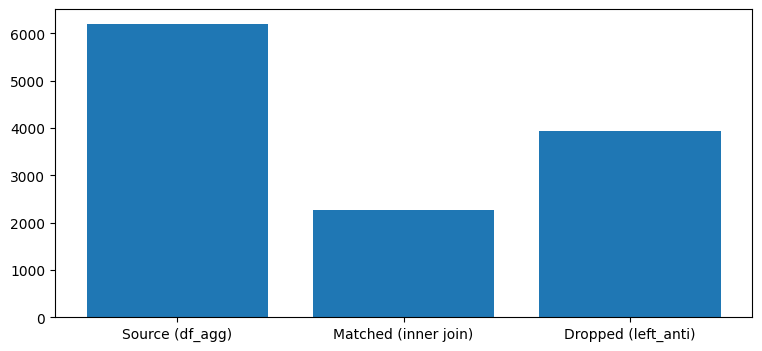

In [30]:
# =================================================
# Show plot #1
# =================================================

buildJoined_DroppedResultPlot(df_agg, df_master_site)

<h3>Build the Data as the foundation</h3>


In [31]:
node_index_column_name = 'NODE_INDEX'
total_calls_column_name = "TOTAL_CALLS"
cell_csfb_rate_column_name = 'CELL_CSFB_RATE'
cell_pingpong_rate_column_name = 'CELL_PINGPONG_RATE'
cell_total_ping_pong_ho_count_column_name = 'CELL_TOTAL_PING_PONG_HO_COUNT'
# cell_success_rate_column_name = 'CELL_SUCCESS_RATE'
cell_drop_rate_column_name = 'CELL_DROP_RATE'
total_csfb_calls_column_name = 'TOTAL_CSFB_CALLS'
total_setup_fail_calls_column_name = 'TOTAL_SETUP_FAIL_CALLS'
total_calls_column_name = 'TOTAL_CALLS'
setup_fail_call_flag_column_name = 'SETUP_FAIL_CALL_FLAG'


total_foundation_data_rows: Optional[int] = None

df_source: Optional[DataFrame] = None
df_foundation: Optional[DataFrame] = None

# retrieve existing data to prevent dependency on previous process
df_source = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{join_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


df_foundation = (
    df_source
    .withColumn(cell_csfb_rate_column_name, fn.col(total_csfb_calls_column_name) / fn.col(total_calls_column_name))
    .withColumn(cell_pingpong_rate_column_name, fn.col(cell_total_ping_pong_ho_count_column_name) / fn.col(total_calls_column_name))
    .withColumn(setup_fail_call_flag_column_name, (fn.coalesce(fn.col(total_setup_fail_calls_column_name), fn.lit(0)) > 0).cast("int"))
)


total_foundation_data_rows = df_foundation.count()

if (total_foundation_data_rows > 0):
    print(f'\ntotal row of foundation data : {df_foundation.count()}')

    # df_foundation.select('*').where(fn.column(node_index_column_name) == 1462).show()

    df_foundation.write.mode("overwrite").option("header", True).parquet(foundation_dir)
    df_foundation.orderBy(node_index_column_name).show(10, truncate=False)


total row of foundation data : 2262
+----------+------+-----------+-------------------------------------+--------------------------------+------------+-----------+----------+------------+-------+---------+------+------+----------+---------+----------+------+-----------------------+--------------+-------+-----------+-----------+---+---+---------------------+------+------------+---------+----------+----------+-------------------+----------------+-----------------+----------------+----------------------+-----------+------------------+---------------------+---------------+-------------------+-------------------+------------------+-------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+-----------------------------+---------------------+------------------+--------------------+
|NODE_INDEX|SITEID|MOD_CELL_ID|CELLNAME                             |SITENAME                        |SITE_TYPE   |REGION     |KABU

<h3>Retrieve Top-K values from each SOURCE_CELL</h3>


In [32]:
# filter from normalized cell_traces where :
# - CALL_STATUS = 1
# - START_CELL_ID != NULL
# - END_CELL_ID != NULL
# - START_CELL_ID != END_CELL_ID

df_ho_raw: Optional[DataFrame] = None
df_ho_agg: Optional[DataFrame] = None
df_top_k: Optional[DataFrame] = None

src_cell_id_column_name = 'SRC_CELL_ID'
dst_cell_id_column_name = 'DST_CELL_ID'
src_cell_column_name = 'SOURCE_CELL'
dst_cell_column_name = 'DEST_CELL'
call_status_column_name = 'CALL_STATUS'
start_cell_id_column_name = 'START_CELL_ID'
end_cell_id_column_name = 'END_CELL_ID'
ho_count_column_name = 'HO_COUNT'
rn_column_name = 'ROW_NUMBER'

total_ho_raw_rows = None
total_ho_agg_rows = None
total_top_k_rows = None


df_ho_raw = (
    df_ct_normalized.select('*').where(
        (fn.col(call_status_column_name) == 1)
        &
        (fn.col(src_cell_id_column_name) != fn.col(dst_cell_id_column_name))
    ).select(
        fn.col(src_cell_id_column_name).alias(src_cell_column_name),
        fn.col(dst_cell_id_column_name).alias(dst_cell_column_name)
    )
)

total_ho_raw_rows = df_ho_raw.count()

if (total_ho_raw_rows > 0):
    print(f'total ho_raw rows : {total_ho_raw_rows}')

    df_ho_agg = (
        df_ho_raw.groupBy(src_cell_column_name, dst_cell_column_name).count().orderBy(
            fn.col(src_cell_column_name).asc()
        ).withColumnRenamed('count', ho_count_column_name).orderBy(src_cell_column_name, dst_cell_column_name)
    )


total_ho_agg_rows = df_ho_agg.count()

# df_ho_agg.groupBy(src_cell_column_name).count().orderBy(fn.col(src_cell_column_name)).show(100, truncate=False)

if (total_ho_agg_rows > 0):
    print(f'total ho_agg rows : {total_ho_agg_rows}')

    print('\nOriginal Result : ')
    # df_ho_agg.groupBy(
    #     fn.col(src_cell_column_name)
    # ).count().withColumnRenamed('count', 'TOTAL_ROW').orderBy(
    #     fn.col(src_cell_column_name).asc()
    # ).show(10, truncate=False)
    # .show(10, truncate=False)

    # df_ho_agg.orderBy(fn.col(src_cell_column_name).asc(), fn.col(dst_cell_column_name).asc()).show(10, truncate=False)


# ======================================
# Retrieve the top-K to prevent Noise
# ======================================


window: Optional[Window] = None

# create windows condition
window = ww.partitionBy(src_cell_column_name).orderBy(fn.col(ho_count_column_name).desc())

# Filter only top-K
df_top_k = (
    df_ho_agg.withColumn(rn_column_name, fn.row_number().over(window)).where(
        fn.col(rn_column_name) <= K_VALUE
    ).drop(rn_column_name)
)

total_top_k_rows = df_top_k.count()

if (total_top_k_rows > 0):
    print(f'total top_k rows : {total_top_k_rows} \n')

    print(f'\nTop {K_VALUE} for each source_cell Result : ')
    df_top_k.write.mode("overwrite").option("header", True).parquet(top_k_dir)

    # df_top_k.groupBy(
    #     fn.col(src_cell_column_name)
    # ).count().withColumnRenamed('count', 'TOTAL_ROW').orderBy(
    #     fn.col(src_cell_column_name).asc()
    # ).show(10, truncate=False)
    # .orderBy(fn.col(src_cell_column_name).asc(), fn.col(dst_cell_column_name).asc()).show(10, truncate=False)

    df_top_k.orderBy(fn.col(src_cell_column_name).asc(), fn.col(dst_cell_column_name).asc()).show(10, truncate=False)

total ho_raw rows : 88141229


total ho_agg rows : 556538

Original Result : 


total top_k rows : 556538 


Top 1000 for each source_cell Result : 


+-----------+---------+--------+
|SOURCE_CELL|DEST_CELL|HO_COUNT|
+-----------+---------+--------+
|147002_11  |147002_12|6192    |
|147002_11  |147002_13|3468    |
|147002_11  |147002_14|597     |
|147002_11  |147002_21|1464    |
|147002_11  |147002_22|1368    |
|147002_11  |147002_23|1358    |
|147002_11  |147002_24|63      |
|147002_11  |147002_31|1645    |
|147002_11  |147002_32|256     |
|147002_11  |147002_33|539     |
+-----------+---------+--------+
only showing top 10 rows


<h3>Reindex the Node</h3>


In [33]:
window: Optional[Window] = None

df_initial: Optional[DataFrame] = None
df_reindex: Optional[DataFrame] = None

node_index_column_name = 'NODE_INDEX'

# retrieve existing data to prevent dependency on previous process
df_initial = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{foundation_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


# Remap the NODE_INDEX value to start from 0
window = ww.orderBy(fn.col("OLD_NODE_INDEX").asc())

df_reindex = (
    df_initial.select(
        fn.col(node_index_column_name).alias('OLD_NODE_INDEX')
    ).distinct().withColumn(
        'NEW_NODE_INDEX', (fn.row_number().over(window) - 1).cast('int')
    )
)

df_initial = (
    df_initial.alias('t').join(
        df_reindex.alias('r'),
        (fn.col(f't.{node_index_column_name}') == fn.col('r.OLD_NODE_INDEX')),
        how='inner'
    ).drop(
        fn.col(node_index_column_name), fn.col('OLD_NODE_INDEX')
    ).withColumnRenamed(
        'NEW_NODE_INDEX', node_index_column_name
    ).orderBy(
        fn.col(node_index_column_name).asc()
    )
)


total_row = df_initial.count()

if (total_row > 0):
    print(f"\nTotal rows : {total_row} \n\n")
    df_initial.show(10, truncate=False)

    # df_xls = df_labeled.orderBy(fn.col(node_index_column_name)).toPandas()
    # df_xls.to_excel("/home/arry/Downloads/output.xlsx", index=False)

    df_initial.write.mode("overwrite").option("header", True).parquet(initial_dir)


Total rows : 2262 




26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+------+-----------+-------------------------------------+--------------------------------+------------+-----------+----------+------------+-------+---------+------+------+----------+---------+----------+------+-----------------------+--------------+-------+-----------+-----------+---+---+---------------------+------+------------+---------+----------+----------+-------------------+----------------+-----------------+----------------+----------------------+-----------+------------------+---------------------+---------------+-------------------+-------------------+------------------+-------------------+------------------+-----------------+--------------------+--------------------+--------------------+--------------------+-----------------------------+---------------------+------------------+--------------------+----------+
|SITEID|MOD_CELL_ID|CELLNAME                             |SITENAME                        |SITE_TYPE   |REGION     |KABUPATEN |KECAMATAN   |LAC_TAC|ENODEB_ID|GNB_ID|RNC

26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/25 10:53:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


<h3>*** Map cell_id to node_index ***</h3>


In [34]:
df_nodes: Optional[DataFrame] = None
df_edges: Optional[DataFrame] = None
df_initial: Optional[DataFrame] = None
df_top_k: Optional[DataFrame] = None

node_index_column_name = 'NODE_INDEX'
cell_id_column_name = 'CELL_ID'
mod_cell_id_column_name = 'MOD_CELL_ID'
src_index_column_name = 'SOURCE_INDEX'
dst_index_column_name = 'DEST_INDEX'


edges_undirected_total_row: Optional[int] = None


# retrieve existing data to prevent dependency on previous process
df_initial = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{initial_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


# retrieve existing data to prevent dependency on previous process
df_top_k = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{top_k_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


df_nodes = (
    df_initial.select(
        fn.col(node_index_column_name),
        fn.col(mod_cell_id_column_name).alias(cell_id_column_name)
    )
)

df_edges = (
    df_top_k.join(
        df_nodes.withColumnRenamed(cell_id_column_name, src_cell_column_name),
        on=src_cell_column_name,
        how='inner'
    ).withColumnRenamed(
        node_index_column_name, src_index_column_name
    ).join(
        df_nodes.withColumnRenamed(cell_id_column_name, dst_cell_column_name),
        on=dst_cell_column_name,
        how='inner'
    ).withColumnRenamed(
        node_index_column_name, dst_index_column_name
    ).select(src_index_column_name, dst_index_column_name, ho_count_column_name)
)


edges_undirected_total_row = df_edges.count()

if (edges_undirected_total_row > 0):
    print(f'total row of df_edges : {edges_undirected_total_row}')
    df_edges.printSchema()
    df_edges.orderBy(src_index_column_name, dst_index_column_name).show(10, truncate=False)
    df_edges.write.mode("overwrite").option("header", True).parquet(edges_dir)

total row of df_edges : 427749
root
 |-- SOURCE_INDEX: integer (nullable = true)
 |-- DEST_INDEX: integer (nullable = true)
 |-- HO_COUNT: long (nullable = true)

+------------+----------+--------+
|SOURCE_INDEX|DEST_INDEX|HO_COUNT|
+------------+----------+--------+
|0           |4         |1       |
|0           |5         |1       |
|0           |8         |1       |
|0           |10        |1       |
|0           |16        |173     |
|0           |36        |1       |
|0           |42        |1       |
|0           |43        |1       |
|0           |54        |1       |
|0           |83        |1       |
+------------+----------+--------+
only showing top 10 rows


<h3>*** Build Edge OUT and IN information for each NODE ***</h3>


In [35]:
df_edges: Optional[DataFrame] = None
df_out_agg: Optional[DataFrame] = None
df_in_agg: Optional[DataFrame] = None
df_edges_grouping: Optional[DataFrame] = None


node_index_column_name = 'NODE_INDEX'
src_index_column_name = 'SOURCE_INDEX'
dst_index_column_name = 'DEST_INDEX'

edges_grouping_total_row: Optional[int] = None

# retrieve existing data to prevent dependency on previous process
df_edges = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{edges_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


# build df for OUT information
df_out_agg = (
    df_edges.groupby(
        fn.col(src_index_column_name)
    ).agg(
        fn.sum(ho_count_column_name).alias('OUT_HO_SUM'),
        fn.count('*').alias('OUT_EDGE_COUNT'),
        fn.countDistinct(dst_index_column_name).alias('OUT_NEIGHBOR_COUNT'),
    ).withColumnRenamed(src_index_column_name, node_index_column_name)
)

# df_out.orderBy(fn.col(node_index_column_name)).show(10, truncate=False)

# build df for IN information
df_in_agg = (
    df_edges.groupBy(
        fn.col(dst_index_column_name)
    ).agg(
        fn.sum(ho_count_column_name).alias('IN_HO_SUM'),
        fn.count('*').alias('IN_EDGE_COUNT'),
        fn.countDistinct(src_index_column_name).alias('IN_NEIGHBOR_COUNT')
    ).withColumnRenamed(dst_index_column_name, node_index_column_name)
)

# df_in.orderBy(fn.col(node_index_column_name)).show(10, truncate=False)


# build df grouping as the JOIN from df_out_agg and df_in_agg
df_edges_grouping = (
    df_out_agg.join(
        df_in_agg,
        on=node_index_column_name,
        how='full'
    ).fillna(
        0, subset=[
            'OUT_HO_SUM', 'OUT_EDGE_COUNT', 'OUT_NEIGHBOR_COUNT',
            'IN_HO_SUM', 'IN_EDGE_COUNT', 'IN_NEIGHBOR_COUNT'
        ]
    ).withColumn(
        'HO_TOTAL', fn.col('OUT_HO_SUM') + fn.col('IN_HO_SUM')
    ).withColumn(
        "OUT_IN_RATIO", (fn.col("OUT_HO_SUM") + fn.lit(1.0)) / (fn.col("IN_HO_SUM") + fn.lit(1.0))
    )
)
edges_grouping_total_row = df_edges_grouping.count()

if (edges_grouping_total_row > 0):
    print(f'total row of df_edges_grouping : {edges_grouping_total_row}')
    df_edges_grouping.printSchema()
    df_edges_grouping.orderBy(fn.col(node_index_column_name)).show(10, truncate=False)

    df_edges_grouping.write.mode("overwrite").option("header", True).parquet(edges_grouping_dir)

# df_pd = df_edges_grouping.orderBy(fn.col(node_index_column_name)).toPandas()
# df_pd.to_excel("/home/arry/Downloads/output.xlsx", index=False)

total row of df_edges_grouping : 2261
root
 |-- NODE_INDEX: integer (nullable = true)
 |-- OUT_HO_SUM: long (nullable = true)
 |-- OUT_EDGE_COUNT: long (nullable = true)
 |-- OUT_NEIGHBOR_COUNT: long (nullable = true)
 |-- IN_HO_SUM: long (nullable = true)
 |-- IN_EDGE_COUNT: long (nullable = true)
 |-- IN_NEIGHBOR_COUNT: long (nullable = true)
 |-- HO_TOTAL: long (nullable = true)
 |-- OUT_IN_RATIO: double (nullable = true)

+----------+----------+--------------+------------------+---------+-------------+-----------------+--------+-------------------+
|NODE_INDEX|OUT_HO_SUM|OUT_EDGE_COUNT|OUT_NEIGHBOR_COUNT|IN_HO_SUM|IN_EDGE_COUNT|IN_NEIGHBOR_COUNT|HO_TOTAL|OUT_IN_RATIO       |
+----------+----------+--------------+------------------+---------+-------------+-----------------+--------+-------------------+
|0         |11210     |306           |306               |40746    |403          |403              |51956   |0.27513681988858074|
|1         |32552     |131           |131             

<h3>*** Build undirected node table ***</h3>


In [36]:
df_edges: Optional[DataFrame] = None
df_edges_undirected: Optional[DataFrame] = None

src_index_column_name = 'SOURCE_INDEX'
dst_index_column_name = 'DEST_INDEX'
ho_count_column_name = 'HO_COUNT'

edges_undirected_total_row: Optional[int] = None


# retrieve existing data to prevent dependency on previous process
df_edges = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{edges_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


df_edges_undirected = (
    df_edges.unionByName(
        df_edges.select(
            fn.col(dst_index_column_name).alias(src_index_column_name),
            fn.col(src_index_column_name).alias(dst_index_column_name),
            fn.col(ho_count_column_name)
        )
    )
)

edges_undirected_total_row = df_edges_undirected.count()

if (edges_undirected_total_row > 0):
    print("total directed row : ", df_edges.count())
    print("total undirected row :", df_edges_undirected.count())
    print(
        "self loops:",
        df_edges_undirected.filter(
            fn.col(src_index_column_name) == fn.col(dst_index_column_name)
        ).count()
    )

    df_edges_undirected.write.mode("overwrite").option("header", True).parquet(edges_undirected_dir)

total directed row :  427749
total undirected row : 855498
self loops: 0


<h3>Build Final Node Feature</h3>


In [37]:
df_edges_grouping: Optional[DataFrame] = None
df_initial: Optional[DataFrame] = None
df_node_final: Optional[DataFrame] = None

node_final_total_row: Optional[int] = None

node_index_column_name = 'NODE_INDEX'


# retrieve existing data to prevent dependency on previous process
df_initial = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{initial_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)

# retrieve existing data to prevent dependency on previous process
df_edges_grouping = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{edges_grouping_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


df_node_final = (
    df_initial.join(
        df_edges_grouping,
        on=node_index_column_name,
        how='left'
    )
)

node_final_total_row = df_node_final.count()

if (node_final_total_row > 0):
    df_node_final.printSchema()
    df_node_final.write.mode("overwrite").option("header", True).parquet(node_final_dir)
    print("total node_final row : ", node_final_total_row)

root
 |-- NODE_INDEX: integer (nullable = true)
 |-- SITEID: string (nullable = true)
 |-- MOD_CELL_ID: string (nullable = true)
 |-- CELLNAME: string (nullable = true)
 |-- SITENAME: string (nullable = true)
 |-- SITE_TYPE: string (nullable = true)
 |-- REGION: string (nullable = true)
 |-- KABUPATEN: string (nullable = true)
 |-- KECAMATAN: string (nullable = true)
 |-- LAC_TAC: integer (nullable = true)
 |-- ENODEB_ID: double (nullable = true)
 |-- GNB_ID: double (nullable = true)
 |-- RNC_ID: string (nullable = true)
 |-- LONGITUDE: double (nullable = true)
 |-- LATITUDE: double (nullable = true)
 |-- TECHNOLOGY: string (nullable = true)
 |-- BAND: string (nullable = true)
 |-- ANTENNA_MODEL: string (nullable = true)
 |-- ANTENNA_HEIGHT: double (nullable = true)
 |-- AZIMUTH: double (nullable = true)
 |-- AZIMUTH_SIN: double (nullable = true)
 |-- AZIMUTH_COS: double (nullable = true)
 |-- MT: double (nullable = true)
 |-- ET: double (nullable = true)
 |-- HORIZONTAL_BEAM_WIDTH: do

<h3>Build Background Overlay Topology Visualization (Position based on longituted & lattitude, Azimuth as the offset, and color grouping by siteId)</h3>


In [38]:
# buildCellOverlayTopology(df_edges, df_node_final)

<h3>Build GeoLocation Topology Visualization (Position based on longituted & lattitude, Azimuth as the offset, and color grouping by siteId)</h3>


In [39]:
# buildCellGeolocationTopology(df_edges, df_node_final)

<h3>Build Node Feature <ol><li>Matrix (X)</li></ol></h3>


In [46]:
feature_cols: Optional[List] = None
skew_cols: Optional[List] = None
node_features: Optional[np.ndarray] = None

Plot_column_names: List[str] = None
Plot_column_indices: List[int] = None

# this function is just for checking (ignore !)
# def col_max(cols):
#     idx = [i for i, c in enumerate(feature_cols) if c in cols]
#     return {c: float(np.max(node_features[:, feature_cols.index(c)])) for c in cols if c in feature_cols}


check_cols = [
    "TOTAL_CALLS", "CELL_TOTAL_DL_VOLUME", "CELL_TOTAL_UL_VOLUME",
    "OUT_HO_SUM", "IN_HO_SUM", "HO_TOTAL"
]


feature_cols = [
    # --- traffic / call outcomes ---
    "TOTAL_CALLS",
    "TOTAL_SUCCESS_CALLS",
    "TOTAL_DROP_CALLS",
    "TOTAL_BLOCK_CALLS",
    "TOTAL_CSFB_CALLS",
    "TOTAL_SETUP_FAIL_CALLS",
    "CELL_SUCCESS_RATE",
    "CELL_DROP_RATE",
    "CELL_BLOCK_RATE",

    # --- radio / coverage ---
    "CELL_AVG_RSRP",
    "CELL_P10_RSRP",
    "CELL_P90_RSRP",
    "CELL_AVG_RSRQ",
    "CELL_AVG_TA",
    "CELL_P90_TA",

    # --- throughput / volume ---
    "CELL_AVG_DL_THROUPUT",
    "CELL_AVG_UL_THROUPUT",
    "CELL_TOTAL_DL_VOLUME",
    "CELL_TOTAL_UL_VOLUME",
    "CELL_TOTAL_PING_PONG_HO_COUNT",

    # --- antenna / geometry ---
    "ANTENNA_HEIGHT",
    "AZIMUTH_SIN",
    "AZIMUTH_COS",
    "MT",
    "ET",
    "HORIZONTAL_BEAM_WIDTH",
    "LONGITUDE",
    "LATITUDE",
    "LAC_TAC",

    # --- topology / direction ---
    "OUT_HO_SUM",
    "IN_HO_SUM",
    "OUT_EDGE_COUNT",
    "IN_EDGE_COUNT",
    "OUT_NEIGHBOR_COUNT",
    "IN_NEIGHBOR_COUNT",
    "HO_TOTAL",
    "OUT_IN_RATIO",
]


skew_cols = {
    "TOTAL_CALLS",
    "TOTAL_SUCCESS_CALLS",
    "TOTAL_DROP_CALLS",
    "TOTAL_BLOCK_CALLS",
    "TOTAL_CSFB_CALLS",
    "TOTAL_SETUP_FAIL_CALLS",
    "CELL_TOTAL_DL_VOLUME",
    "CELL_TOTAL_UL_VOLUME",
    "CELL_TOTAL_PING_PONG_HO_COUNT",
    "OUT_HO_SUM",
    "IN_HO_SUM",
    "HO_TOTAL",
    "OUT_EDGE_COUNT",
    "IN_EDGE_COUNT",
    "OUT_NEIGHBOR_COUNT",
    "IN_NEIGHBOR_COUNT",
}

# make sure the DF is sorted by node_index
df_node_final = df_node_final.orderBy(node_index_column_name)

# df_node_final.orderBy(fn.col(node_index_column_name)).show(20, truncate=False)
# output_csv = os.path.join(str('/home/arry/Downloads'), "data.csv")
# df_panda = df_node_final.toPandas()
# df_panda.to_csv(output_csv, index=False)


# build node features
node_features = (
    df_node_final.select(
        feature_cols
    ).fillna(0.0).toPandas().values
)


# print("max check:", col_max(check_cols))

# ==============================================================================================================
# build the variables needed for plot#4
# ==============================================================================================================
node_features_before_log1p = node_features.copy()
Plot_column_names, Plot_column_indices = buildFeatureColumNameAndIndices(feature_cols, skew_cols)


# ==============================================================================================================
# APPLYING  'log1p transformation'   (this function is intended to shrinks big numbers and reduces skew)
# ==============================================================================================================

skew_idx = [i for i, c in enumerate(feature_cols) if c in skew_cols]

# reassign the value
node_features = node_features.astype(np.float32)
node_features[:, skew_idx] = np.log1p(np.clip(node_features[:, skew_idx], 0, None))

# print(f"node_features min : {np.nanmin(node_features)}, max : {np.nanmax(node_features)}")
# print("max check:", col_max(check_cols))

print(node_features.shape)

(2262, 37)


<h3>Plot #2 : Feature transform on skewed columns</h3>


In [ ]:

# ==============================================================
# Displayplot #4
# ==============================================================
buildFeatureTransformForSkewedColumnPlot(node_features, node_features_before_log1p, Plot_column_names, Plot_column_indices)

<h3>Build numpy array for : <ol><li>edge_index</li><li>edge_weight</li></ol></h3>


In [26]:
df_edges_undirected: Optional[DataFrame] = None

np_edge_index: Optional[np.ndarray] = None
np_edge_weight: Optional[np.ndarray] = None

src_index_column_name = 'SOURCE_INDEX'
dst_index_column_name = 'DEST_INDEX'
ho_count_column_name = 'HO_COUNT'

# retrieve existing data to prevent dependency on previous process
df_edges_undirected = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .option("mode", "PERMISSIVE")
    .option("nullValue", "\\N")             # treat \N as null
    .option("nanValue", "NaN")              # treat "NaN" as actual NaN
    .parquet(f'{edges_undirected_dir}')
).replace([" ", "", "NULL", "nan", "NaN"], None)


print(f'size df_edges_undirected : {df_edges_undirected.count()}')
# df_edges_undirected.printSchema()

np_edge_index = (
    df_edges_undirected.select(
        src_index_column_name, dst_index_column_name
    ).toPandas().values.T  # the result is numpY array
)

print(f'size np_edge_index : {np_edge_index.shape}')

np_edge_weight = (
    df_edges_undirected.select(
        ho_count_column_name
    ).toPandas().values.reshape(-1)  # the result is numpY array
)

size df_edges_undirected : 855498
size np_edge_index : (2, 855498)


<h1>Build PyTorchGeometric (PyG) Data</h1>


<h3>Convert from numpyArray to Tensors Data Type for :
<ol>
    <li>Node features</li>
    <li>Edge Index</li>
    <li>Edge Weight</li>
</ol>
</h3>


In [27]:
torch_x: Optional[torch.Tensor] = None
torch_edge_index: Optional[torch.Tensor] = None
torch_edge_weight: Optional[torch.Tensor] = None
edge_weight_before_preprocess_plot3: Optional[np.ndarray] = None
edge_weight_after_preprocess_plot3: Optional[np.ndarray] = None
torchData: Optional[Data] = None


def preprocess_edge_weight(data, cap_quantile=CAP_QUANTILE_THRESHOLD, eps=EPS_THRESHOLD):

    if not hasattr(data, "edge_weight") or data.edge_weight is None:
        return data

    w = data.edge_weight.float()

    # 1) safety: HO count should be non-negative
    w = torch.clamp(w, min=0.0)

    # 2) log1p: compress heavy tail
    w = torch.log1p(w)

    # 3) cap extreme edges (p99 by default)
    if 0.0 < cap_quantile < 1.0:
        cap = torch.quantile(w, cap_quantile)
        w = torch.clamp(w, max=cap)

    # 4) normalize so average weight ~ 1 (stable training)
    w = w / (w.mean().clamp(min=eps))

    data.edge_weight = w
    return data


torch_x = torch.tensor(node_features, dtype=torch.float)
torch_edge_index = torch.tensor(np_edge_index, dtype=torch.long)
torch_edge_weight = torch.tensor(np_edge_weight, dtype=torch.float)

print(f'size torch_edge_index : {torch_edge_index.shape}')

torchData = Data(x=torch_x, edge_index=torch_edge_index)

# set the edge_weight to torchData
torchData.edge_weight = torch_edge_weight


# ====================================================
# Build the object for Plot #3 — BEFORE preprocessing
# ====================================================
edge_weight_before_preprocess_plot3 = torchData.edge_weight.detach().cpu().numpy().copy()


# Normalize the edge weight
torchData = preprocess_edge_weight(torchData, cap_quantile=CAP_QUANTILE_THRESHOLD)


# ====================================================
# Build the object for Plot 3 — AFTER preprocessing
# ====================================================
edge_weight_after_preprocess_plot3 = torchData.edge_weight.detach().cpu().numpy().copy()

size torch_edge_index : torch.Size([2, 855498])


<h3>Plot #3 : Edge weight distribution + preprocessing</h3>


[PLOT5] edge_weight BEFORE preprocess (raw HO count)
min=1.000000 p50=2.000000 p95=491.000000 p99=3699.000000 max=204197.000000 mean=181.014784
[PLOT5] edge_weight AFTER preprocess (log1p + cap + normalize)
min=0.340714 p50=0.540018 p95=3.046836 p99=4.038583 max=4.038583 mean=1.000000


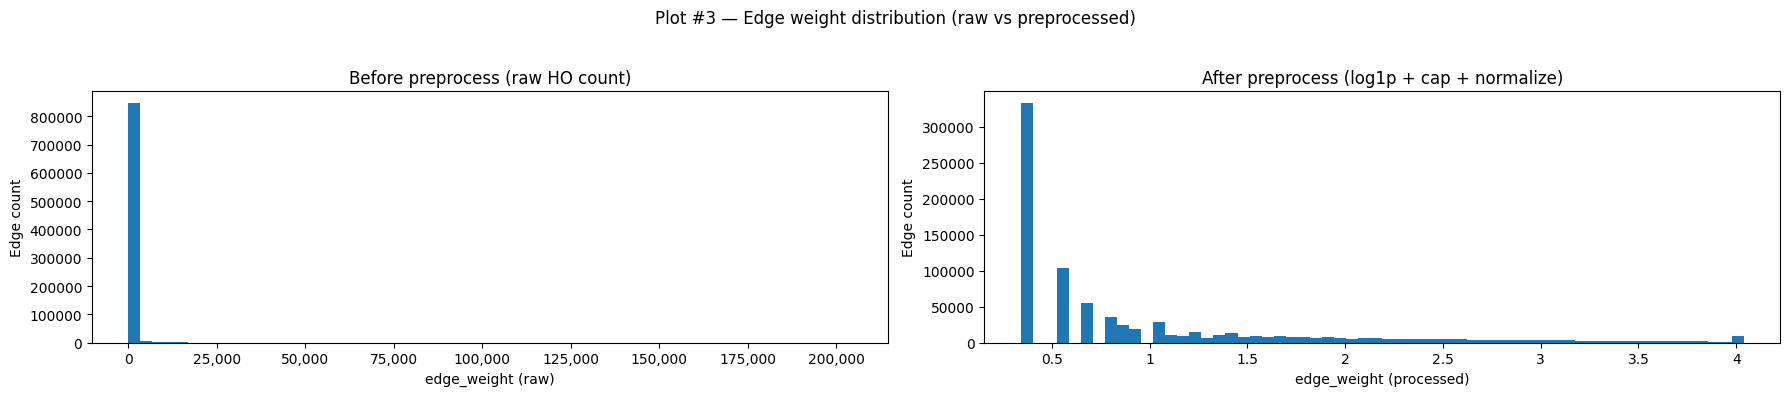

In [28]:
# ====================================================
# Show Plot #3
# ====================================================

buildEdgeWeightDistributionPlot(
    edge_weight_before=edge_weight_before_preprocess_plot3,
    edge_weight_after=edge_weight_after_preprocess_plot3,
    bins=60,
    title_prefix="Plot #3 — Edge weight distribution (raw vs preprocessed)"
)

<h3>Plot #4: Graph Topology and Connectivity Analysis </h3>


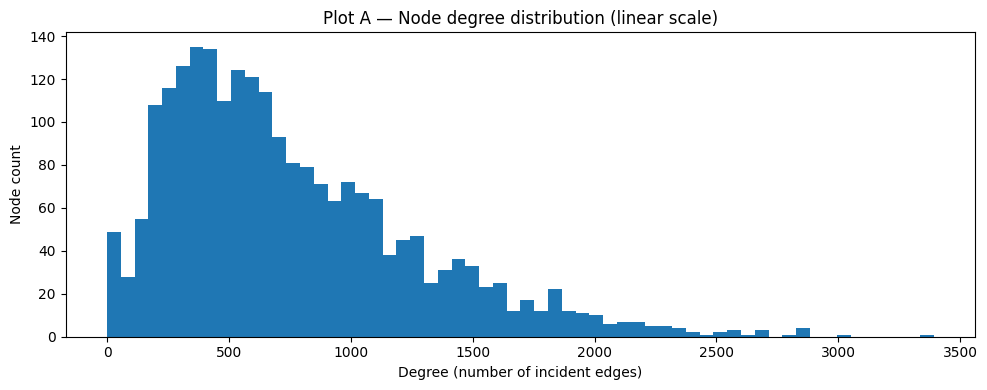

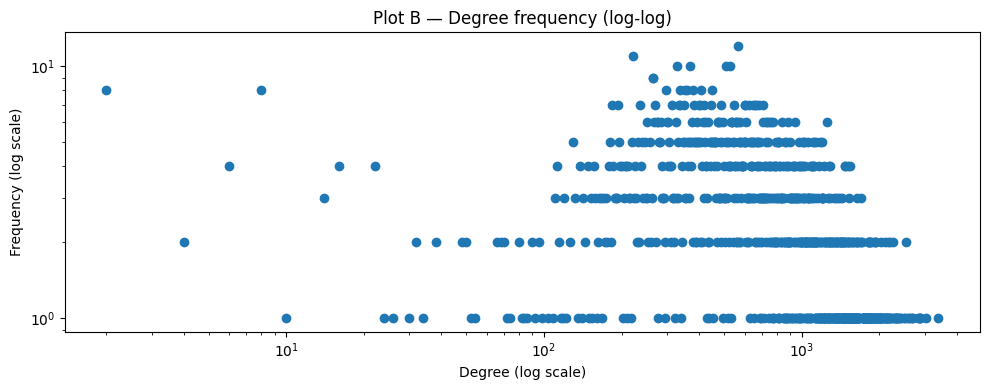

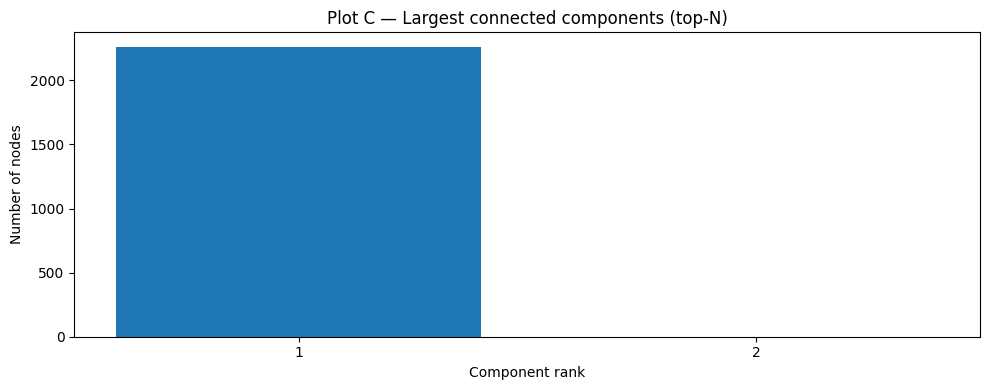

[PLOT6] num_nodes=2,262  num_edges=855,498
[PLOT6] number_of_components=2
[PLOT6] largest_component_size=2,261
[PLOT6] top5_component_sizes=[2261, 1]


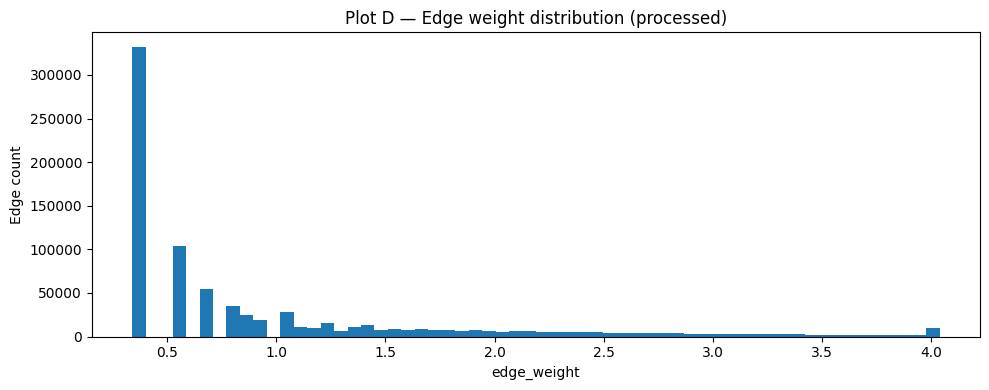

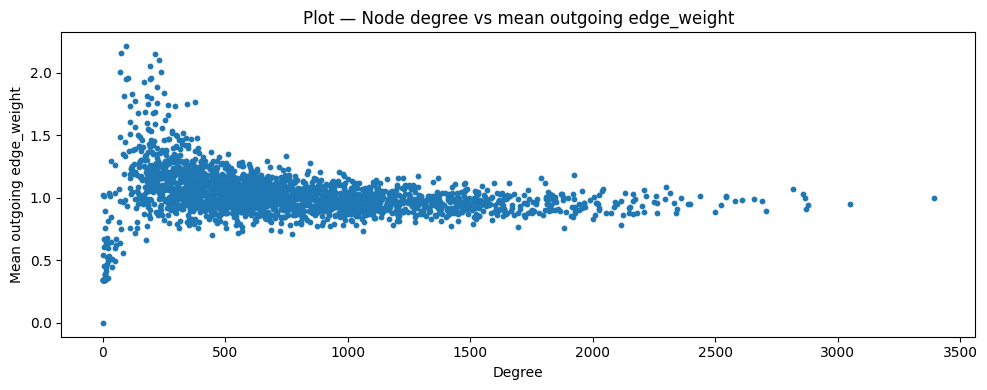

In [29]:
# ====================================================
# Show Plot #4
# ====================================================

buildGraphTopology_ConnectivityPlot(torchData)

In [30]:
print(f'number Of Nodes : {node_final_total_row}')
print("min of torch_edge_index :", int(torch_edge_index.min()))
print(f'max of torch_edge_index : {torch_edge_index.max()}')

number Of Nodes : 2262
min of torch_edge_index : 0
max of torch_edge_index : 2261


<h3>Graph Sanity Checks</h3>


In [31]:
if "int" in globals() and globals()["int"] is not builtins.int:
    del int
if "float" in globals() and globals()["float"] is not builtins.float:
    del float
if "max" in globals() and globals()["max"] is not builtins.max:
    del max
if "min" in globals() and globals()["min"] is not builtins.min:
    del min
if "sum" in globals() and globals()["sum"] is not builtins.sum:
    del sum


def tensorHasNanOrInf(t: torch.Tensor) -> Tuple[bool, bool]:
    has_nan = bool(torch.isnan(t).any().item())
    has_inf = bool(torch.isinf(t).any().item())
    return has_nan, has_inf


def countIsolatedNodes(data: Data) -> int:
    if data.edge_index is None:
        return int(data.num_nodes)

    edge_index = data.edge_index
    num_nodes = int(data.num_nodes)

    if edge_index.numel() == 0:
        return num_nodes

    src = edge_index[0]
    dst = edge_index[1]

    deg = torch.bincount(
        torch.cat([src, dst], dim=0),
        minlength=num_nodes
    )
    isolated = int((deg == 0).sum().item())
    return isolated


def assert_pygGraphSanity(
    data: Data,
    *,
    require_edge_weight: bool = True,
    require_non_negative_edge_weight: bool = True,
    fail_on_isolated_nodes: bool = False,
    log_prefix: str = "SANITY"
) -> Dict[str, int]:
    if data.x is None:
        raise ValueError(f"{log_prefix}: data.x is None")

    if data.edge_index is None:
        raise ValueError(f"{log_prefix}: data.edge_index is None")

    if data.x.dim() != 2:
        raise ValueError(f"{log_prefix}: data.x must be 2D [N, F], got dim={data.x.dim()}")

    if data.edge_index.dim() != 2 or int(data.edge_index.size(0)) != 2:
        raise ValueError(
            f"{log_prefix}: data.edge_index must be shape [2, E], got {tuple(data.edge_index.shape)}"
        )

    num_nodes = int(data.x.size(0))
    num_edges = int(data.edge_index.size(1))

    if num_nodes <= 0:
        raise ValueError(f"{log_prefix}: num_nodes must be > 0, got {num_nodes}")

    if num_edges <= 0:
        raise ValueError(f"{log_prefix}: num_edges must be > 0, got {num_edges}")

    min_idx = int(data.edge_index.min().item())
    max_idx = int(data.edge_index.max().item())

    if min_idx < 0:
        raise ValueError(f"{log_prefix}: edge_index has negative node id, min={min_idx}")

    if max_idx >= num_nodes:
        raise ValueError(
            f"{log_prefix}: edge_index references node id out of range, max={max_idx}, num_nodes={num_nodes}"
        )

    x_nan, x_inf = tensorHasNanOrInf(data.x)
    if x_nan or x_inf:
        raise ValueError(f"{log_prefix}: data.x has_nan={x_nan}, has_inf={x_inf}")

    if require_edge_weight:
        if not hasattr(data, "edge_weight") or data.edge_weight is None:
            raise ValueError(f"{log_prefix}: edge_weight is required but missing")

        if data.edge_weight.dim() != 1:
            raise ValueError(
                f"{log_prefix}: edge_weight must be 1D [E], got {tuple(data.edge_weight.shape)}"
            )

        if int(data.edge_weight.numel()) != num_edges:
            raise ValueError(
                f"{log_prefix}: edge_weight length mismatch, edge_weight={int(data.edge_weight.numel())}, edges={num_edges}"
            )

        w_nan, w_inf = tensorHasNanOrInf(data.edge_weight)
        if w_nan or w_inf:
            raise ValueError(f"{log_prefix}: edge_weight has_nan={w_nan}, has_inf={w_inf}")

        if require_non_negative_edge_weight:
            w_min = float(data.edge_weight.min().item())
            if w_min < 0.0:
                raise ValueError(f"{log_prefix}: edge_weight has negative value, min={w_min}")

    isolated_nodes = countIsolatedNodes(data)
    if fail_on_isolated_nodes and isolated_nodes > 0:
        raise ValueError(f"{log_prefix}: isolated nodes found: {isolated_nodes}")

    print(
        f"{log_prefix}: OK"
        f"\nnodes={num_nodes}"
        f"\nedges={num_edges}"
        f"\nedge_idx_range=[{min_idx},{max_idx}]"
        f"\nisolated_nodes={isolated_nodes}"
    )

    return {
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "isolated_nodes": isolated_nodes
    }


# Print out the normalize result
# =================================================================================
w = torchData.edge_weight
print(
    "edge_weight stats:",
    "\nmin : ", float(w.min().item()),
    "\nmedian : ", float(w.median().item()),
    "p95", float(torch.quantile(w, 0.95).item()),
    "max", float(w.max().item()),
    "mean", float(w.mean().item()),
)

sanity_info = assert_pygGraphSanity(
    torchData,
    require_edge_weight=True,
    require_non_negative_edge_weight=True,
    fail_on_isolated_nodes=False,
    log_prefix="SANITY"
)

edge_weight stats: 
min :  0.3407135605812073 
median :  0.5400182008743286 p95 3.0468358993530273 max 4.038583278656006 mean 1.0
SANITY: OK
nodes=2262
edges=855498
edge_idx_range=[0,2261]
isolated_nodes=1


<h3>Enforce Directed / Undirected for Graph</h3>


In [32]:
GraphDirection = Literal["directed", "undirected"]
ReduceMode = Literal["sum", "mean", "min", "max"]


def enforceGraphDirection(
    data: Data,
    *,
    direction: GraphDirection = "undirected",
    reduce_mode: ReduceMode = "sum",
    log_prefix: str = "GRAPH"
) -> Data:
    if data.edge_index is None:
        raise ValueError(f"{log_prefix}: edge_index is None")

    if not hasattr(data, "edge_weight") or data.edge_weight is None:
        raise ValueError(f"{log_prefix}: edge_weight is required for direction enforcement")

    edge_index = data.edge_index
    edge_weight = data.edge_weight

    # Ensure correct dtypes
    if edge_index.dtype != torch.long:
        edge_index = edge_index.long()
    if edge_weight.dtype not in (torch.float16, torch.float32, torch.float64):
        edge_weight = edge_weight.float()

    num_nodes = builtins.int(data.num_nodes)

    if direction == "directed":
        # Still coalesce to remove duplicates and keep a single weight per edge.
        edge_index2, edge_weight2 = coalesce(
            edge_index=edge_index,
            edge_attr=edge_weight,
            num_nodes=num_nodes,
            reduce=reduce_mode
        )
        data.edge_index = edge_index2
        data.edge_weight = edge_weight2

        print(
            f"{log_prefix}: kept DIRECTED"
            f"\nedges(before)={builtins.int(edge_index.size(1))}"
            f"\nedges(after)={builtins.int(edge_index2.size(1))}"
            f"\nreduce={reduce_mode}"
        )
        return data

    if direction == "undirected":
        # Convert while carrying weights. Then coalesce duplicates.
        edge_index_u, edge_weight_u = to_undirected(
            edge_index=edge_index,
            edge_attr=edge_weight,
            num_nodes=num_nodes
        )

        edge_index2, edge_weight2 = coalesce(
            edge_index=edge_index_u,
            edge_attr=edge_weight_u,
            num_nodes=num_nodes,
            reduce=reduce_mode
        )
        data.edge_index = edge_index2
        data.edge_weight = edge_weight2

        print(
            f"{log_prefix}: converted to UNDIRECTED"
            f"\n========================================"
            f"\nedges(before)={builtins.int(edge_index.size(1))}"
            f"\nedges(undirected)={builtins.int(edge_index_u.size(1))}"
            f"\nedges(after_coalesce)={builtins.int(edge_index2.size(1))}"
            f"\nreduce={reduce_mode}"
        )
        return data

    raise ValueError(f"{log_prefix}: invalid direction={direction}")


# invoke above method
# =================================================================================
torchData = enforceGraphDirection(
    torchData,
    direction="undirected",
    reduce_mode="sum",          # sum all over the duplicated Handover node
    log_prefix="GRAPH"
)

GRAPH: converted to UNDIRECTED
edges(before)=855498
edges(undirected)=602250
edges(after_coalesce)=602250
reduce=sum


<h3>Reproducibility control and GPU execution setup</h3>


In [33]:
def setGlobalSeed(
    seed: int,
    *,
    deterministic: bool = True,
    log_prefix: str = "SEED"
) -> Dict[str, object]:
    seed_i = builtins.int(seed)

    # Python and NumPy
    random.seed(seed_i)
    np.random.seed(seed_i)

    # Torch CPU and CUDA
    torch.manual_seed(seed_i)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_i)
        torch.cuda.manual_seed_all(seed_i)

    # Optional determinism settings for thesis runs
    if deterministic:
        # Reproducibility
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # These env flags are recommended for deterministic on some GPUs
        # If environment disallows it, it will be ignored.
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            # Some may not support deterministic mode, avoid crash
            pass
    else:
        # Speed first
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

    info = {
        "seed": seed_i,
        "deterministic": builtins.bool(deterministic),
        "cuda_available": builtins.bool(torch.cuda.is_available()),
        "torch_version": torch.__version__
    }

    print(
        f"{log_prefix}:\nseed={info['seed']}"
        f"\ndeterministic={info['deterministic']}"
        f"\ncuda_available={info['cuda_available']}"
        f"\ntorch={info['torch_version']}"
    )
    return info


def getDevice(*, prefer_cuda: bool = True, log_prefix: str = "DEVICE") -> torch.device:
    use_cuda = prefer_cuda and torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    if device.type == "cuda":
        idx = torch.cuda.current_device()
        name = torch.cuda.get_device_name(idx)
        print(f"{log_prefix}: cuda:{idx} ({name})")
    else:
        print(f"{log_prefix}: cpu")

    return device


def move_pygDataToDevice(data: Data, device: torch.device, *, log_prefix: str = "DATA") -> Data:
    if data is None:
        raise ValueError(f"{log_prefix}: data is None")

    data = data.to(device)

    print(
        f"\n{log_prefix} is processed using {device.type}"
        f"\nx_device={data.x.device}"
        f"\nedge_index_device={data.edge_index.device}"
        f"\nedge_weight_device={getattr(data, 'edge_weight', None).device if getattr(data, 'edge_weight', None) is not None else 'None'}"
    )
    return data


# invoke above method
# =================================================================================
seed_info = setGlobalSeed(RUN_SEEDS[0], deterministic=True, log_prefix="SEED")
device = getDevice(prefer_cuda=True, log_prefix="DEVICE")
torchData = move_pygDataToDevice(torchData, device, log_prefix="DATA")

SEED:
seed=0
deterministic=True
cuda_available=True
torch=2.9.0+cu128
DEVICE: cuda:0 (NVIDIA GeForce RTX 2070)

DATA is processed using cuda
x_device=cuda:0
edge_index_device=cuda:0
edge_weight_device=cuda:0


<h3>Edge Partitioning for Unsupervised Link Reconstruction</h3>


In [34]:
def splitEdgesForLinkReconstruction(
    data: Data,
    *,
    val_ratio: float = 0.05,
    test_ratio: float = 0.10,
    add_negative_train_samples: bool = False,
    is_undirected: bool = True,
    log_prefix: str = "SPLIT"
) -> Tuple[Data, Data, Data, Dict[str, int]]:
    if data.edge_index is None:
        raise ValueError(f"{log_prefix}: edge_index is None")

    num_nodes = builtins.int(data.num_nodes)
    num_edges = builtins.int(data.edge_index.size(1))

    if num_nodes <= 0 or num_edges <= 0:
        raise ValueError(f"{log_prefix}: invalid graph size nodes={num_nodes} edges={num_edges}")

    transform = RandomLinkSplit(
        num_val=val_ratio,
        num_test=test_ratio,
        is_undirected=is_undirected,
        add_negative_train_samples=add_negative_train_samples,
        split_labels=True
    )

    train_data, val_data, test_data = transform(data)

    # Info for logging
    info = {
        "num_nodes": builtins.int(train_data.num_nodes),
        "edges_total_before": num_edges,
        "train_pos_edges": builtins.int(train_data.pos_edge_label_index.size(1)),
        "val_pos_edges": builtins.int(val_data.pos_edge_label_index.size(1)),
        "test_pos_edges": builtins.int(test_data.pos_edge_label_index.size(1))
    }

    # Negative edges exist for val/test by default
    if hasattr(val_data, "neg_edge_label_index") and val_data.neg_edge_label_index is not None:
        info["val_neg_edges"] = builtins.int(val_data.neg_edge_label_index.size(1))
    else:
        info["val_neg_edges"] = 0

    if hasattr(test_data, "neg_edge_label_index") and test_data.neg_edge_label_index is not None:
        info["test_neg_edges"] = builtins.int(test_data.neg_edge_label_index.size(1))
    else:
        info["test_neg_edges"] = 0

    print(
        f"{log_prefix}: RandomLinkSplit"
        f"\nnodes={info['num_nodes']}"
        f"\nedges_before={info['edges_total_before']}"
        f"\ntrain_pos={info['train_pos_edges']}"
        f"\nval_pos={info['val_pos_edges']}"
        f"\ntest_pos={info['test_pos_edges']}"
        f"\nval_neg={info['val_neg_edges']}"
        f"\ntest_neg={info['test_neg_edges']}"
    )

    return train_data, val_data, test_data, info


# invoke above method
# =================================================================================

# trainData, valData, testData, split_info = split_edges_for_link_reconstruction(
#     torchData,
#     val_ratio=0.05,
#     test_ratio=0.10,
#     add_negative_train_samples=False,
#     is_undirected=True,
#     log_prefix="SPLIT type "
# )

trainData, valData, testData, split_info = splitEdgesForLinkReconstruction(
    torchData,
    val_ratio=0.05,
    test_ratio=0.10,
    add_negative_train_samples=True,
    is_undirected=True,
    log_prefix="SPLIT type "
)

print("\n\ntrain edge_index E:", builtins.int(trainData.edge_index.size(1)))
print("val edge_index E:", builtins.int(valData.edge_index.size(1)))
print("val pos edges:", builtins.int(valData.pos_edge_label_index.size(1)))
print("test pos edges:", builtins.int(testData.pos_edge_label_index.size(1)))

SPLIT type : RandomLinkSplit
nodes=2262
edges_before=602250
train_pos=255957
val_pos=15056
test_pos=30112
val_neg=15056
test_neg=30112


train edge_index E: 511914
val edge_index E: 511914
val pos edges: 15056
test pos edges: 30112


<h3>GAE Training Process</h3>


In [35]:
inputFeatures = int(trainData.x.size(1))

# instantiate GAE model
# gaeModel, gaeOptimizer = buildModelAndOptimizer(
#     model_kind="gae",
#     inputFeatures=inputFeatures,
#     hiddenChannels=HIDDEN_CHANNELS,
#     latentChannels=LATENT_CHANNELS,
#     # dropout=DROPOUT,
#     dropout=0.4,
#     lr=LEARNING_RATE,
#     weight_decay=WEIGHT_DECAY,
#     device=device,
#     log_prefix="MODEL"
# )

# gae_result = trainGAE(
#     gaeModel=gaeModel,
#     gaeOptimizer=gaeOptimizer,
#     trainData=trainData,
#     valData=valData,
#     max_epochs=MAX_EPOCHS,
#     patience=PATIENCE,
#     log_every=LOG_EVERY,
#     min_epoch_before_early_stopping=MIN_EPOCH_BEFORE_EARLY_STOPPING,
#     use_ema_for_early_stopping=USE_EMA_FOR_EARLY_STOPPING,
#     ema_beta=EMA_BETA,
#     min_delta=MIN_DELTA,
#     grad_clip_norm=GRAD_CLIP_NORM,
#     normalize_z_before_recon=NORMALIZE_Z_BEFORE_RECON,
#     log_prefix="TRAIN_GAE"
# )

# CHECKPOINT

# training_config = {
#     "hidden_channels": HIDDEN_CHANNELS,
#     "latent_channels": LATENT_CHANNELS,
#     "dropout": DROPOUT,
#     "lr": LEARNING_RATE,
#     "weight_decay": WEIGHT_DECAY,
# }

# result = runOneConfig_gae(
#     trainData=trainData,
#     valData=valData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=training_config,
#     seeds=RUN_SEEDS,
#     log_prefix="TRAIN GAE",
#     plot_mode="representative",
#     plot_one_seed=True,
# )


# print(f'result : {result}')

<h3>VGAE Training Process</h3>


In [36]:
inputFeatures = int(trainData.x.size(1))

# # instantiate VGAE model
# # vgaeModel, vgaeOptimizer = buildModelAndOptimizer(
# #     model_kind="vgae",
# #     inputFeatures=inputFeatures,
# #     hiddenChannels=HIDDEN_CHANNELS,
# #     latentChannels=LATENT_CHANNELS,
# #     dropout=DROPOUT,
# #     lr=LEARNING_RATE,
# #     weight_decay=WEIGHT_DECAY,
# #     device=device,
# #     log_prefix="MODEL"
# # )

# # vgae_result = trainVGAE(
# #     vgaeModel=vgaeModel,
# #     vgaeOptimizer=vgaeOptimizer,
# #     trainData=trainData,
# #     valData=valData,
# #     max_epochs=MAX_EPOCHS,
# #     patience=PATIENCE,
# #     log_every=LOG_EVERY,
# #     kl_beta=KL_BETA,
# #     log_prefix="TRAIN_VGAE"
# # )


# training_config = {
#     "hidden_channels": HIDDEN_CHANNELS,
#     "latent_channels": LATENT_CHANNELS,
#     "dropout": DROPOUT,
#     "lr": LEARNING_RATE,
#     "weight_decay": WEIGHT_DECAY,
#     "kl_beta": KL_BETA
# }

# result = runOneConfig_vgae(
#     trainData=trainData,
#     valData=valData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=training_config,
#     seeds=RUN_SEEDS,
#     log_prefix="TRAIN VGAE",
#     plot_mode="representative",
#     plot_one_seed=True,
# )

# print(f'result : {result}')

<h3>DGI Training Process</h3>


In [37]:
inputFeatures = int(trainData.x.size(1))

# instantiate DGI model
# dgiModel, dgiOptimizer = buildModelAndOptimizer(
#     model_kind="dgi",
#     inputFeatures=inputFeatures,
#     hiddenChannels=HIDDEN_CHANNELS,
#     latentChannels=LATENT_CHANNELS,
#     dropout=DROPOUT,
#     lr=LEARNING_RATE,
#     weight_decay=WEIGHT_DECAY,
#     device=device,
#     log_prefix="MODEL"
# )

# dgi_result = trainDGI(
#     dgiModel=dgiModel,
#     dgiOptimizer=dgiOptimizer,
#     data=torchData,
#     max_epochs=MAX_EPOCHS,
#     patience=PATIENCE,
#     log_every=LOG_EVERY,
#     log_prefix="TRAIN_DGI"
# )

# training_config = {
#     "hidden_channels": HIDDEN_CHANNELS,
#     "latent_channels": LATENT_CHANNELS,
#     "dropout": DROPOUT,
#     "lr": LEARNING_RATE,
#     "weight_decay": WEIGHT_DECAY
# }

# result = runOneConfig_dgi(
#     data=torchData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=training_config,
#     seeds=RUN_SEEDS,
#     log_prefix=f"TRAIN DGI",
#     plot_mode='representative',
#     plot_one_seed=True,
# )

# print(f'result : {result}')

<h3>Hyperparameter Tuning for GAE, VGAE, DGI</h3>


In [38]:
# inputFeatures = int(trainData.x.size(1))

# gae_rows = trainModelsUsingAllParameter(
#     model_kind="gae",
#     hyperparam_values=HYPERPARAMETER_VALUES,
#     base_cfg=BASE_GAE,
#     seeds=RUN_SEEDS,
#     inputFeatures=inputFeatures,
#     device=device,
#     trainData=trainData,
#     valData=valData,
#     log_prefix="HYPERPARAMETER_TUNING",
#     plot_mode="representative",
#     plot_one_seed=False,   # key point: do not plot while sweeping
# )
# gae_best_per_param = chooseBestValuePerParameter(rows=gae_rows, model_kind="gae")

# print("\n=== BEST PER PARAM (GAE) ===")
# for r in gae_best_per_param:
#     print(r)


# vgae_rows = trainModelsUsingAllParameter(
#     model_kind="vgae",
#     hyperparam_values=HYPERPARAMETER_VALUES,
#     base_cfg=BASE_VGAE,
#     seeds=RUN_SEEDS,
#     inputFeatures=inputFeatures,
#     device=device,
#     trainData=trainData,
#     valData=valData,
#     log_prefix="HYPERPARAMETER_TUNING",
#     plot_mode="representative",
#     plot_one_seed=False,
# )
# vgae_best_per_param = chooseBestValuePerParameter(rows=vgae_rows, model_kind="vgae")

# print("\n=== BEST PER PARAM (VGAE) ===")
# for r in vgae_best_per_param:
#     print(r)


# dgi_rows = trainModelsUsingAllParameter(
#     model_kind="dgi",
#     hyperparam_values=HYPERPARAMETER_VALUES,
#     base_cfg=BASE_DGI,
#     seeds=RUN_SEEDS,
#     inputFeatures=inputFeatures,
#     device=device,
#     data=torchData,
#     log_prefix="HYPERPARAMETER_TUNING",
#     plot_mode="representative",
#     plot_one_seed=False,
# )
# dgi_best_per_param = chooseBestValuePerParameter(rows=dgi_rows, model_kind="dgi")


# print("\n=== BEST PER PARAM (DGI) ===")
# for r in dgi_best_per_param:
#     print(r)

<h3>Run the Training based on HyperParameter Optimal</h3>


In [39]:
# gae_final_cfg = {
#     "hidden_channels": 128,
#     "latent_channels": 64,
#     "dropout": 0.2,
#     "lr": 0.0005,
#     "weight_decay": 0.0,
# }

# result = runOneConfig_gae(
#     trainData=trainData,
#     valData=valData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=gae_final_cfg,
#     seeds=RUN_SEEDS,
#     log_prefix="GAE_FINAL_PLOT combined best parameter",
#     plot_mode="representative",
#     plot_one_seed=True,
# )

# vgae_training_config = {
#     "hidden_channels": 128,
#     "latent_channels": 32,
#     "dropout": 0.2,
#     "lr": 0.0005,
#     "weight_decay": 0.00001,
#     "kl_beta": 0.001
# }

# result = runOneConfig_vgae(
#     trainData=trainData,
#     valData=valData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=vgae_training_config,
#     seeds=RUN_SEEDS,
#     log_prefix="VGAE_FINAL_PLOT combined best parameter",
#     plot_mode="representative",
#     plot_one_seed=True,
# )

# dgi_training_config = {
#     "hidden_channels": 64,
#     "latent_channels": 32,
#     "dropout": 0,
#     "lr": 0.0008,
#     "weight_decay": 0.00001
# }

# result = runOneConfig_dgi(
#     data=torchData,
#     inputFeatures=inputFeatures,
#     device=device,
#     cfg=dgi_training_config,
#     seeds=RUN_SEEDS,
#     log_prefix=f"TRAIN DGI",
#     plot_mode='representative',
#     plot_one_seed=True,
# )


# print(f'result : {result}')

<h3>Clustering and Evaluation Metrics</h3>


In [91]:
def run_clustering_and_evaluation(model_name: str, z_np: np.ndarray, log_prefix: str = "EVAL") -> List[Dict[str, Any]]:
    """
    Executes both DBSCAN and HDBSCAN for Section 4.9.2 and evaluates them for 4.9.3.
    """
    # 1. Standardize latent space for distance stability
    z_scaled = StandardScaler().fit_transform(z_np)
    results = []

    # Define Clustering Tasks for Section 4.9.2
    clustering_tasks = {
        "HDBSCAN": hdbscan.HDBSCAN(
            # min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            min_cluster_size=15,
            min_samples=HDBSCAN_MIN_SAMPLES,
            metric='euclidean'
        ),
        "DBSCAN": DBSCAN(
            # eps=DBSCAN_EPS,
            eps=2.0,
            min_samples=HDBSCAN_MIN_SAMPLES
        )
    }

    for algo_name, clusterer in clustering_tasks.items():
        print(f"{log_prefix} [{model_name} - {algo_name}]: Clustering...")
        labels = clusterer.fit_predict(z_scaled)

        # 3. Handle Noise and Cluster Count for Evaluation
        mask = labels != -1
        unique_labels = np.unique(labels[mask])
        n_clusters = builtins.len(unique_labels)
        noise_pts = builtins.int((labels == -1).sum())

        # Metric Logic for Section 4.9.3
        s_score, dbi_score, ch_score = None, None, None
        if n_clusters >= 2:
            s_score = silhouette_score(z_scaled[mask], labels[mask])
            dbi_score = davies_bouldin_score(z_scaled[mask], labels[mask])
            ch_score = calinski_harabasz_score(z_scaled[mask], labels[mask])

            print(f"--- {model_name} ({algo_name}) RESULTS ---")
            print(f"Clusters : {n_clusters} | Noise : {noise_pts} ({(noise_pts/builtins.len(labels))*100:.2f}%)")
            print(f"Silhouette: {s_score:.4f} | DBI: {dbi_score:.4f} | CH: {ch_score:.4f}\n")
        else:
            print(f"{log_prefix} [{model_name}-{algo_name}]: Not enough clusters for metrics.\n")

        results.append({
            "model": model_name,
            "algorithm": algo_name,
            "labels": labels,
            "n_clusters": n_clusters,
            "noise_pts": noise_pts,
            "silhouette": s_score,
            "dbi": dbi_score,
            "ch": ch_score
        })

    return results

<h3>Extract last state of Model Embedding stored in the directory</h3>


In [57]:
# 1. Read Model's embedding last state
all_embeddings = extract_final_embeddings(gaeModel, vgaeModel, dgiModel, torchData, model_training_result_path)

# 2. Verify the results
if all_embeddings:
    print("\n--- Summary of Extracted Embeddings ---")
    for name, z_np in all_embeddings.items():
        print(f"Model: {name:4} | Shape: {z_np.shape} | Mean: {z_np.mean():.4f}")
else:
    print("ERROR: No embeddings were extracted !")

Loading GAE embedding from best saved state: /data/geolocation-data/processed/cell_traces/model_training_result/gae_z_embedding.npy
Loading VGAE embedding from best saved state: /data/geolocation-data/processed/cell_traces/model_training_result/vgae_z_embedding.npy
Loading DGI embedding from best saved state: /data/geolocation-data/processed/cell_traces/model_training_result/dgi_z_embedding.npy

--- Summary of Extracted Embeddings ---
Model: GAE  | Shape: (2262, 64) | Mean: 0.0024
Model: VGAE | Shape: (2262, 32) | Mean: -0.0068
Model: DGI  | Shape: (2262, 32) | Mean: -0.0091


<h3>Run The Clustering and Evaluation Metrics</h3>


In [93]:
# 1. Run Clustering and Evaluation for each model
final_comparison_data = []

if all_embeddings:
    for model_name, z_values in all_embeddings.items():
        # Execute the clustering function we just reviewed
        # It runs both DBSCAN and HDBSCAN for each Z-space
        comparison_results = run_clustering_and_evaluation(
            model_name=model_name,
            z_np=z_values,
            log_prefix="THESIS_EVAL"
        )

        if comparison_results:
            final_comparison_data.extend(comparison_results)

# 2. Create the Final Summary Table
    if final_comparison_data:
        import pandas as pd

        # Convert results to DataFrame and drop the raw labels for the summary view
        df_summary = pd.DataFrame(final_comparison_data).drop(columns=['labels'])

        print("\n" + "="*80)
        print("TABLE: COMPARISON OF EMBEDDING MODELS AND CLUSTERING ALGORITHMS")
        print("="*80)
        display(df_summary)

        # Save to CSV
        summary_csv = os.path.join(str(clustering_result_path), "clustering_comparison.csv")
        df_summary.to_csv(summary_csv, index=False)
        print(f"\nSummary table saved to: {summary_csv}")
else:
    print("CRITICAL ERROR: No embeddings found. Clustering cannot proceed.")

THESIS_EVAL [GAE - HDBSCAN]: Clustering...
--- GAE (HDBSCAN) RESULTS ---
Clusters : 2 | Noise : 273 (12.07%)
Silhouette: 0.1952 | DBI: 0.9220 | CH: 119.1431

THESIS_EVAL [GAE - DBSCAN]: Clustering...
--- GAE (DBSCAN) RESULTS ---
Clusters : 2 | Noise : 407 (17.99%)
Silhouette: 0.2022 | DBI: 0.9028 | CH: 114.5409

THESIS_EVAL [VGAE - HDBSCAN]: Clustering...
--- VGAE (HDBSCAN) RESULTS ---
Clusters : 6 | Noise : 1165 (51.50%)
Silhouette: 0.5060 | DBI: 0.5000 | CH: 1070.3271

THESIS_EVAL [VGAE - DBSCAN]: Clustering...
THESIS_EVAL [VGAE-DBSCAN]: Not enough clusters for metrics.

THESIS_EVAL [DGI - HDBSCAN]: Clustering...
--- DGI (HDBSCAN) RESULTS ---
Clusters : 2 | Noise : 300 (13.26%)
Silhouette: 0.2089 | DBI: 1.1850 | CH: 30.2020

THESIS_EVAL [DGI - DBSCAN]: Clustering...
--- DGI (DBSCAN) RESULTS ---
Clusters : 3 | Noise : 783 (34.62%)
Silhouette: 0.2685 | DBI: 1.0333 | CH: 22.3700


TABLE: COMPARISON OF EMBEDDING MODELS AND CLUSTERING ALGORITHMS


,model,algorithm,n_clusters,noise_pts,silhouette,dbi,ch
0,GAE,HDBSCAN,2,273,0.195197,0.922028,119.143066
1,GAE,DBSCAN,2,407,0.202176,0.902760,114.540863
2,VGAE,HDBSCAN,6,1165,0.505982,0.500026,1070.327148
3,VGAE,DBSCAN,1,177,NaN,NaN,NaN
4,DGI,HDBSCAN,2,300,0.208887,1.184977,30.201982
5,DGI,DBSCAN,3,783,0.268526,1.033261,22.369959



Summary table saved to: /data/geolocation-data/processed/cell_traces/clustering_result/clustering_comparison.csv


<h3>Merging Clusters with Node Data via NODE_INDEX</h3>


In [ ]:
try:
    # 1. Load the original node data from Parquet
    df_nodes = spark.read.parquet(node_final_dir)

    # 2. Retrieve the VGAE-HDBSCAN labels results (numpy array)
    vgae_res = next((item for item in final_comparison_data if item["model"] == "VGAE" and item["algorithm"] == "HDBSCAN"), None)

    if vgae_res is not None:
        labels_np = vgae_res["labels"]

        # 3. Create a PySpark DataFrame for the labels
        # Convert numpy array to a list of tuples (index, label)
        labels_list = [(int(i), int(l)) for i, l in enumerate(labels_np)]

        # Create DF for labels
        df_labels_raw = spark.createDataFrame(labels_list, ["NODE_INDEX", "label_int"])

        # Transform integer labels to 'Cluster_X' or 'Noise' strings
        df_labels = df_labels_raw.withColumn(
            "cluster_label",
            fn.when(fn.col("label_int") == -1, "Noise").otherwise(fn.concat(fn.lit("Cluster_"), fn.col("label_int").cast("string")))
        ).drop("label_int")

        # 4. Perform the Join on NODE_INDEX
        df_final = df_nodes.join(df_labels, on="NODE_INDEX", how="left")

        # 5. Reorder columns
        all_cols = df_final.columns
        all_cols.remove("cluster_label")
        node_idx_pos = all_cols.index("NODE_INDEX")

        # Insert cluster_label at Index 1
        all_cols.insert(node_idx_pos + 1, "cluster_label")

        df_final = df_final.select(*all_cols)

        # 6. Save the final result to the clustering_result_path
        output_path = os.path.join(str(clustering_result_path), "node_clustering_result")

        df_final.coalesce(1).orderBy(fn.column('cluster_label').asc()).write.mode("overwrite") \
            .option("header", "true") \
            .csv(output_path)

        print(f"Successfully joined {df_final.count()} rows.")
        print(f"Result saved to CSV directory: {output_path}")

        # 7. Show All Columns for the result
        print("\n" + "="*80)
        print("FINAL PYSPARK DATAFRAME PREVIEW")
        print("="*80)

        # Displaying a sample showing the new column order
        df_final.orderBy(fn.column('cluster_label').asc()).show(10, truncate=False)

        # Show count per cluster
        print("\nCluster Distribution:")
        df_final.groupBy("cluster_label").count().orderBy("cluster_label").show()

    else:
        print("Error: VGAE-HDBSCAN results not found in 'final_comparison_data'.")

except Exception as e:
    print(f"An error occurred during PySpark mapping: {e}")

Successfully joined 2262 rows.
Result saved to CSV directory: /data/geolocation-data/processed/cell_traces/clustering_result/node_clustering_result

FINAL PYSPARK DATAFRAME PREVIEW
+----------+-------------+------+-----------+------------------------------------------+-------------------------------------+---------+-----------+----------+-------------+-------+---------+------+------+----------+---------+----------+------+-------------+--------------+-------+-----------+-----------+---+---+---------------------+------+------------+---------+----------+----------+-------------------+----------------+-----------------+----------------+----------------------+-----------+------------------+---------------------+---------------+-------------------+-------------------+------------------+-------------------+------------------+----------------+--------------------+--------------------+--------------------+--------------------+-----------------------------+---------------------+-----------------